---
>「百聞は一見に如かず」
>
> 『漢書』趙充国伝

---

# VLM（Vision-Language Model）— 画像を見て文章で答えるLLMの仕組み

本テキストでは、画像を入力として受け取り、文章で答える**VLM（Vision-Language Model、視覚言語モデル）**の内部構造を、自分の手で組み立てながら学ぶ

これまでのテキストで、画像と言語を結びつける部品はすでに学んでいる

- 画像をパッチの列として扱うViT（`mlsys-text-K-1-ViT-US.ipynb` を参照）
- 画像と文を同じ空間に埋め込むCLIP（`mlsys-text-J-NLP-7-CLIP-GD.ipynb` を参照）
- 次の単語を予測し続けることで文章を生成するGPT（`mlsys-text-J-NLP-6-GPT-full.ipynb` を参照）
- 画像に説明文を付けるGITやBLIP（`mlsys-text-N-アプリ-transformer.ipynb`、`mlsys-text-L-Diffusion-1.ipynb` を参照）

一方、ChatGPTやGeminiのように「画像を見せて質問すると文章で答える」モデルが、内部でこれらの部品をどうつないでいるのかは、まだ扱っていない
`mlsys-text-M-LLM-1-Basics.ipynb` の「マルチモーダルLLM」では製品を概観したので、本テキストではその**中身**を扱う

本テキストでは以下を扱う：

1. **CLIPからVLMへ**: CLIPにできること、できないこと
2. **VLMの基本構造**: 画像エンコーダ、接続部（プロジェクタ）、LLMの3部品と「画像トークン」の考え方
3. **接続方式の系統**: 射影、問い合わせトークン、クロスアテンションの比較
4. **最小のVLMの自作**: 凍結した画像エンコーダと凍結した小型言語モデルの間で、小さなプロジェクタだけを学習する
5. **2段階の学習**: 特徴の位置合わせと指示チューニング
6. **解像度・画像トークン数・計算量**: 細かく見るほど高くつく理由
7. **公開されている小型VLMを動かす**: 写真、図表、文書、複数画像への質問と、苦手な例
8. **マルチモーダルRAG**: 画像を検索してからVLMに答えさせる
9. **その先**: 動画、音声、画像生成まで行う統合モデル、ロボット制御（VLA）

---

# この講義でできるようになること

- VLMが「画像エンコーダ ＋ 接続部 ＋ LLM」の3部品でできていることを、図とコードの両方で説明できるようになる
- 画像パッチの特徴を「画像トークン」に変換してLLMに読ませる処理を、自分で実装できるようになる
- 解像度と画像トークン数と計算量の関係を見積もり、用途に合った設定を選べるようになる
- 公開されている小型VLMを動かし、得意な課題と苦手な課題を自分で確かめられるようになる
- 画像検索とVLMを組み合わせたマルチモーダルRAGを組めるようになる

# 全体像

まず、本テキストの流れを俯瞰する

<img src="https://class.west.sd.keio.ac.jp/dataai/text/vlm-overview.png" width=750>

上の図の上段は仕組みを自分で作って学ぶ部分、下段は公開されているVLMを使って確かめる部分である

1. CLIPで画像と文の類似度を測り、「選べるが書けない」ことを確かめる
2. 画像エンコーダの出力を、言語モデルの単語埋め込みと同じ次元のベクトル列（画像トークン）に変換する
3. プロジェクタだけを学習させ、学習前はでたらめだった出力が、画像に関係する説明文に変わることを確認する
4. 接続方式を変えて（49個の画像トークン → 8個の問い合わせトークン）、性能と計算量を比べる
5. 言語モデル側も学習させる「指示チューニング」を小規模に試す
6. 公開されている小型VLMで、質問応答、図表と文書の読み取り、複数画像の比較を試し、失敗例も観察する
7. CLIPによる画像検索とVLMをつなぎ、マルチモーダルRAGを組む

全体をColabのT4で実行できる規模にしてある
学習を伴うのは3〜5の部分で、それ以外は推論だけである

---

# 準備

Hugging Faceの `transformers`（モデル）と `datasets`（データセット）を使う
Colabには最初から入っているが、入っていない環境のために導入セルを置く

- 本テキストで使うモデルとデータセットはすべて公開されており、APIキーもログインも不要である

In [1]:
# 必要なライブラリの導入（Colabでは導入済みのため数秒で終わる）
!pip install -q transformers datasets

In [2]:
# ライブラリの読み込みと、乱数シード・デバイスの設定
import copy
import io
import os
import random
import re
import time

# GPUメモリの断片化を抑える設定（torch を読み込む前に行う必要がある）
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from PIL import Image, ImageDraw, ImageFont
from transformers import (AutoModelForCausalLM, AutoModelForImageTextToText,
                          AutoProcessor, AutoTokenizer, CLIPModel, CLIPProcessor)

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## データセット: Flickr8k

画像と説明文（キャプション）の対として、**Flickr8k**（Hodosh et al., 2013）を使う

- 写真共有サイトの写真約8000枚に、人手で書いた英語の説明文が1枚あたり5文付いている
- 人や犬が何かをしている場面が多く、説明文は「誰が、どこで、何をしている」という短い文である
- Hugging Face Hubの `jxie/flickr8k` はParquet形式で置かれており、`load_dataset` だけで取得できる

学習用の6000枚（約830MB）を取得し、最後の200枚を評価用に取り分ける

- 評価用の画像は学習に使わない
  - 学習に使った画像で説明文が出ても、丸暗記と区別できないためである

In [3]:
# Flickr8kの学習用分割（6000枚、説明文は1枚につき5文）を取得する
ds = load_dataset("jxie/flickr8k", split="train")
print(ds)

# 説明文だけを先に取り出しておく（画像を復号しないので速い）
caps = [[r[f"caption_{k}"].strip() for k in range(5)] for r in ds.remove_columns("image")]

N = len(ds)       # 全画像数
NT = N - 200      # 先頭NT枚を学習用、残り200枚を評価用にする
val_ids = list(range(NT, N))
print("train:", NT, "val:", len(val_ids))

README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

data/train-00000-of-00002-2f8f6bfa852eac(…): reconstructing file:   0%|          |  0.00B /  414MB            

data/train-00000-of-00002-2f8f6bfa852eac(…): downloading bytes:           |  0.00B            

data/train-00001-of-00002-2173151d8cd6c7(…): reconstructing file:   0%|          |  0.00B /  414MB            

data/train-00001-of-00002-2173151d8cd6c7(…): downloading bytes:           |  0.00B            

...

data/test-00000-of-00001-42a2661d12c73e4(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
    num_rows: 6000
})
train: 5800 val: 200


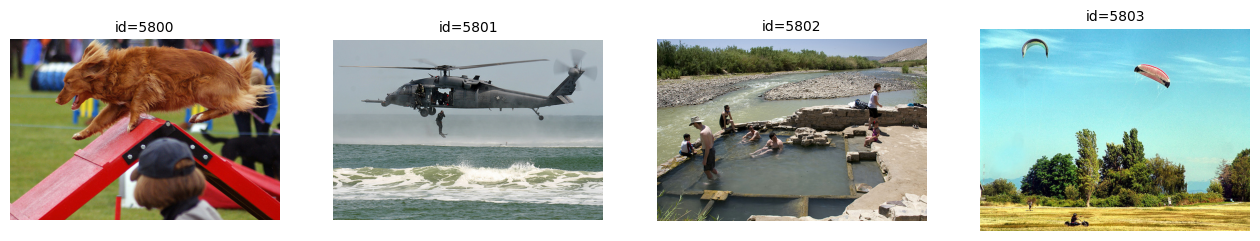

[5800] A brown dog is doing amazing stunts in the dog show . / A brown dog leaps over a red ramp at an agility park .
[5801] A grey helicopter hovering while someone drops in the ocean . / A man in a wetsuit divind out of a helicopter low over the ocean .
[5802] People in or near water with trees in the background . / people lounge in a man made pool , next to a river
[5803] A bike in a field and two kites / A kid is riding a bike in an open field .


In [4]:
# 評価用画像の先頭4枚と、その説明文（5文のうち2文）を表示する
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, i in zip(axes, val_ids[:4]):
    ax.imshow(ds[i]["image"])
    ax.set_title(f"id={i}", fontsize=10)
    ax.axis("off")
plt.show()
for i in val_ids[:4]:
    print(f"[{i}]", caps[i][0], "/", caps[i][1])

---

# CLIPからVLMへ

## CLIPにできること

CLIPは、画像エンコーダとテキストエンコーダを対照学習で同時に学習し、対応する画像と文の埋め込みが近くなるようにしたモデルである

ここでは仕組みは繰り返さず、**VLMの部品として**CLIPを読み込む
画像エンコーダ（ViT-B/32）の出力には2種類あり、本テキストでは両方を使う

| 出力 | 形 | 意味 | 本テキストでの用途 |
| --- | --- | --- | --- |
| 画像全体の埋め込み | 512次元のベクトル1本 | 画像1枚を1点に要約したもの | 類似度の計算、画像検索（マルチモーダルRAG） |
| パッチごとの特徴 | 49本 × 768次元 | 画像を $7 \times 7$ に区切った各領域の特徴 | VLMの画像トークンの材料 |

<img src="https://class.west.sd.keio.ac.jp/dataai/text/vlm-clip-two-outputs.png" width=700>

上の図のように、同じ画像エンコーダから2種類の出力が得られる

- 224×224の画像を32×32のパッチに切るので、パッチ数は $(224/32)^2 = 49$ である
- ゼロショット分類で使ったのは前者だけであった
- VLMでは後者、つまり**場所ごとの情報を残した特徴**を使う
  - 1本のベクトルに要約すると「どこに何があるか」が失われるためである

In [5]:
# CLIP（ViT-B/32）を読み込む（画像エンコーダとテキストエンコーダの両方を含む）
CLIP_ID = "openai/clip-vit-base-patch32"
clip = CLIPModel.from_pretrained(CLIP_ID).float().to(device).eval()
cproc = CLIPProcessor.from_pretrained(CLIP_ID)

n_vis = sum(p.numel() for p in clip.vision_model.parameters())
print(f"画像エンコーダのパラメータ数: {n_vis/1e6:.1f}M")

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

画像エンコーダのパラメータ数: 87.5M


## 画像エンコーダは1回だけ通す

本テキストでは画像エンコーダを**凍結**（重みを更新しない）して使う

- 凍結するなら、同じ画像からは毎回同じ特徴が出る
- そこで全画像を最初に1回だけ画像エンコーダに通し、結果を保存しておく
  - 以降の学習では画像エンコーダを動かす必要がなくなり、学習が大幅に速くなる
  - 大規模なVLMの学習でも使われる定石である

次のセルは6000枚を処理する
- T4では1〜2分かかる（画像の復号と縮小がCPUで行われるため）

In [6]:
# 全画像を画像エンコーダに通し、パッチ特徴と画像全体の埋め込みを保存する
@torch.no_grad()
def encode_images(images):
    # images: PIL画像のリスト
    px = cproc(images=images, return_tensors="pt")["pixel_values"].to(device)
    out = clip.vision_model(pixel_values=px)
    patches = out.last_hidden_state[:, 1:]                 # 先頭のCLSトークンを除いた49本
    emb = clip.visual_projection(out.pooler_output)         # 画像全体の埋め込み（512次元）
    return patches, F.normalize(emb, dim=-1)

@torch.no_grad()
def encode_texts(texts):
    # 文のリストをCLIPのテキスト埋め込み（512次元、長さ1に正規化）にする
    t = cproc(text=texts, return_tensors="pt", padding=True, truncation=True).to(device)
    emb = clip.text_projection(clip.text_model(**t).pooler_output)
    return F.normalize(emb, dim=-1)

t0 = time.time()
pf, ie = [], []
for i in range(0, N, 100):
    p, e = encode_images(ds[i:i + 100]["image"])
    pf.append(p.half())   # メモリ節約のため半精度で保存する
    ie.append(e)
patch_feats = torch.cat(pf)   # (N, 49, 768)
img_emb = torch.cat(ie)       # (N, 512)
print("patch_feats:", tuple(patch_feats.shape), "img_emb:", tuple(img_emb.shape), f"{time.time()-t0:.0f}s")

patch_feats: (6000, 49, 768) img_emb: (6000, 512) 47s


## CLIPは「選べる」が「書けない」

評価用の画像1枚に対して、説明文の候補を5つ用意し、CLIPに類似度を計算させる

- 候補のうち1つはその画像の正しい説明文、残り4つは別の画像の説明文である

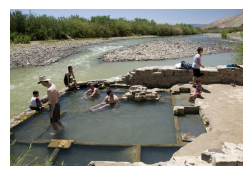

sim=0.292  p=1.000  People in or near water with trees in the background .
sim=0.187  p=0.000  a bicyclist wearing a helmet jumping a trick on his back tire
sim=0.122  p=0.000  Two girls are sitting on a wooden floor in front of a large window .
sim=0.191  p=0.000  A boy with an orange shirt lies on a bodyboard in the surf .
sim=0.163  p=0.000  A girl in a purple tutu dances in the yard .


In [7]:
# 画像1枚と候補文5つの類似度をCLIPで計算する
target = val_ids[2]
cand_ids = [target, val_ids[10], val_ids[20], val_ids[30], val_ids[40]]
cands = [caps[i][0] for i in cand_ids]

sim = (img_emb[target:target + 1] @ encode_texts(cands).T).squeeze(0)   # コサイン類似度
prob = (100 * sim).softmax(dim=0)                                       # 温度付きsoftmax

plt.figure(figsize=(3, 3))
plt.imshow(ds[target]["image"]); plt.axis("off"); plt.show()
for c, s, p in zip(cands, sim.tolist(), prob.tolist()):
    print(f"sim={s:.3f}  p={p:.3f}  {c}")

## 結果の読み方と、CLIPの限界

正しい説明文の類似度が最も高くなり、CLIPは候補の中から合う文を**選ぶ**ことができる

しかし、CLIPにできるのはここまでである

- CLIPの出力は「画像と文がどれだけ合うか」という**数値1つ**である
- 候補文を人間が用意しなければ何も答えられない
  - 「この画像には何が写っているか」「グラフの最大値はいくつか」のような自由な質問には答えられない
- 文章を**生成**する部品（デコーダ）を持っていないためである

文章を生成する能力を持つのはLLMである
そこで、次のように考える

- LLMは「トークンの埋め込みベクトルの列」を入力として受け取り、次のトークンを予測する
- それなら、**画像を埋め込みベクトルの列に変換して、文章の前に並べて入力すればよい**
- LLMから見れば、見慣れない「単語」が先頭に何十個か並んでいるだけである

これがVLMの基本的な発想である

<img src="https://class.west.sd.keio.ac.jp/dataai/text/vlm-clip-vs-vlm.png" width=750>

上の図の左がCLIP、右がVLMである
CLIPの出力は類似度という数値1つであり、VLMは画像トークンをLLMに渡して文章を出力する

CLIPのように画像と文を別々に埋め込んで比べるのではなく、LLMに画像を**読ませる**

---

# VLMの基本構造

## 3つの部品

現在のVLMの多くは、次の3つの部品でできている

| 部品 | 役割 | 典型的な中身 |
| --- | --- | --- |
| **画像エンコーダ**（vision encoder） | 画像をパッチ特徴の列に変換する | CLIPやSigLIPのViT |
| **接続部**（connector、プロジェクタ projector） | パッチ特徴を、LLMの埋め込み空間のベクトル列に変換する | 線形層、MLP、問い合わせトークン方式など |
| **LLM** | 画像トークンとテキストトークンを読み、文章を生成する | デコーダ型のTransformer |

- 画像エンコーダとLLMは、それぞれ別々に事前学習されたものをそのまま持ってくる
  - 画像の見方も、文章の書き方も、すでに学習済みである
- 新しく学習が必要なのは、2つをつなぐ接続部だけである
  - 画像エンコーダの出力は、LLMにとって意味のわからないベクトルである
  - 接続部は、いわば画像エンコーダの言葉をLLMの言葉に直す**通訳**である

次の図に構造を示す

<img src="https://class.west.sd.keio.ac.jp/dataai/text/vlm-architecture.png" width=800>

上の図では、上段が画像の流れ、下段が文章の流れである

- 橙色のプロジェクタだけが学習の対象で、灰色の画像エンコーダとLLMは凍結する
- 図の中の数値は、本テキストで自作するVLMのものである
  - パッチ特徴は49本×768次元で、プロジェクタがこれをLLMの埋め込み次元である576次元に変換する
  - 画像トークン49個とテキストトークン $T$ 個は、同じ576次元のベクトルとして1本の列に並び、LLMに入力される

## 「画像トークン」という考え方

LLMは、入力された文章をトークンに分け、各トークンを**単語埋め込み（word embedding）**の表から引いたベクトルに置き換えてから処理する（`mlsys-text-J-NLP-6-GPT-full.ipynb` を参照）

- LLMの本体（Transformerの各層）が受け取るのは、トークンの番号ではなく**ベクトルの列**である
- したがって、単語埋め込みの表を通さずに、同じ次元のベクトルを直接差し込むことができる

接続部の仕事は、パッチ特徴（768次元）を、LLMの単語埋め込みと同じ次元のベクトルに変換することである
変換後のベクトルを**画像トークン**（image token、visual token）と呼ぶ

<img src="https://class.west.sd.keio.ac.jp/dataai/text/vlm-image-tokens.png" width=750>

上の図の橙色が画像トークン、青色がテキストトークンである
出どころは違うが、LLMの各層から見ればどちらも同じ次元のベクトルである

- 画像トークンは、語彙の中のどの単語にも対応しない
  - 「語彙にはないが、LLMが意味を読み取れるベクトル」を学習で作る
- 入力列は「画像トークン49個、続けてテキストトークン」という1本の列になる
- LLMのアテンションは、テキストトークンから画像トークンを参照できる
  - 画像のどの領域を見るかを、LLM自身のアテンションが決める

次のセルで小型の言語モデルを読み込み、次元を確認する

## 言語モデル: SmolLM2-135M

LLMとして、**SmolLM2-135M**（Hugging Face、パラメータ数約1.35億）を使う

- T4で学習まで行うため、あえて極端に小さいモデルを選ぶ
- デコーダ型のTransformerで、構造はGPTと同じ系統である
- 指示に従うように調整されていない「素の」言語モデルで、与えられた文章の続きを書く
- 実用のVLMは数十億パラメータ以上のLLMを使う
  - 構造は同じで、大きさだけが違うと考えてよい

In [8]:
# 小型の言語モデルを読み込み、単語埋め込みの形を確認する
LM_ID = "HuggingFaceTB/SmolLM2-135M"
tok = AutoTokenizer.from_pretrained(LM_ID)
tok.pad_token = tok.eos_token            # 穴埋め用トークンが未定義のため、文末トークンで代用する
tok.padding_side = "right"
lm = AutoModelForCausalLM.from_pretrained(LM_ID).float().to(device).eval()

E = lm.get_input_embeddings()            # 単語埋め込みの表
D_VIS = patch_feats.shape[-1]            # パッチ特徴の次元
D_LM = lm.config.hidden_size             # 言語モデルの埋め込み次元
print("語彙数 x 埋め込み次元:", tuple(E.weight.shape))
print("パッチ特徴の次元:", D_VIS, "/ 言語モデルの埋め込み次元:", D_LM)
print(f"言語モデルのパラメータ数: {sum(p.numel() for p in lm.parameters())/1e6:.1f}M")

# 文章がベクトルの列に変わる様子を確認する
ids = tok("A dog is running", return_tensors="pt").input_ids.to(device)
print("トークン:", [tok.decode(i) for i in ids[0]], "-> 埋め込みの形:", tuple(E(ids).shape))

config.json:   0%|          | 0.00/704 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.66k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/831 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  269MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

語彙数 x 埋め込み次元: (49152, 576)
パッチ特徴の次元: 768 / 言語モデルの埋め込み次元: 576
言語モデルのパラメータ数: 134.5M
トークン: ['A', ' dog', ' is', ' running'] -> 埋め込みの形: (1, 4, 576)


## 結果の読み方

- パッチ特徴は768次元、言語モデルの埋め込みは576次元で、次元が合わない
  - そのままでは並べて入力することすらできない
- 次元を合わせるだけなら線形層1つで済むが、それだけでは足りない
  - 576次元のどの向きがどんな意味を持つかは、言語モデルが学習の中で決めたものである
  - 画像エンコーダはそれを知らない
- 接続部は「次元を合わせる」だけでなく、**言語モデルが読み取れる向きに特徴を並べ直す**ことを学習する

この学習を、位置合わせ（alignment、アライメント）と呼ぶ

---

# 接続方式の系統

画像エンコーダとLLMのつなぎ方には、大きく3つの系統がある

## 1. 射影方式（線形／MLP）

- パッチ特徴の1本1本を、線形層またはMLPでLLMの埋め込み次元に変換する
- パッチ数と同じ数の画像トークンができる
- LLaVA（Liu et al., 2023）は線形層1つ、LLaVA-1.5は2層のMLPを使った
- 単純で、場所ごとの情報がそのまま残る
- 欠点は、解像度を上げるとトークン数がそのまま増えることである

## 2. 問い合わせトークン方式（query tokens）

- 少数（例: 32個、64個）の学習可能なベクトル（**問い合わせトークン**）を用意する
- 問い合わせトークンがクロスアテンションでパッチ特徴を参照し、必要な情報を取り込む
- 取り込んだ結果を画像トークンとしてLLMに渡す
  - パッチが何個あっても、画像トークンの数は問い合わせトークンの数で固定される
- BLIP-2のQ-Former（32個）、FlamingoのPerceiver Resampler（64個）がこの系統である
- 長所はトークン数を小さく固定できることで、短所は要約の過程で細部や位置の情報が落ちやすいことである

## 3. クロスアテンション挿入方式

- 画像トークンをLLMの入力列には並べない
- LLMの層の間に**クロスアテンション層を新しく差し込み**、各層がそこから画像特徴を参照する
- Flamingo（Alayrac et al., 2022）は、凍結したLLMの層の間にゲート付きのクロスアテンション層を挿入した
  - ゲートの初期値を0にしておき、学習の最初は元のLLMと同じ出力になるようにする
- 長所は、入力列が長くならないことである
  - 画像を何枚入れても、自己アテンションの計算量は増えない
- 短所は、LLMの内部に手を入れるため実装が複雑になり、追加するパラメータも多いことである

次の図に3つの方式を並べる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/vlm-connector-types.png" width=800>

上の図で、$N$ はパッチの数、$K$ は問い合わせトークンの数、$T$ は文章のトークン数である

- (1) と (2) は、画像トークンをLLMの入力列に並べる
  - 違いは、その個数が $N$ か $K$ かである
- (3) は、画像の情報を入力列には並べず、LLMの層の間に差し込んだクロスアテンションから読ませる
- どの方式でも、橙色の部分が新しく学習する部品である

## 3方式の比較

| 観点 | 射影（線形／MLP） | 問い合わせトークン | クロスアテンション挿入 |
| --- | --- | --- | --- |
| LLMに渡す画像トークン数 | パッチ数と同じ（数百〜数千） | 固定の少数（数十） | 0（入力列には並べない） |
| LLMの入力長 | 長くなる | 少し長くなる | 変わらない |
| 新しく学習するパラメータ | 少ない | 中程度 | 多い（層ごとに追加） |
| LLM本体への変更 | 不要 | 不要 | 必要（層の間に挿入） |
| 場所ごとの細かい情報 | 残りやすい | 要約の過程で落ちやすい | 残りやすい |
| 実装の単純さ | 最も単純 | 中程度 | 複雑 |
| 代表例 | LLaVA、LLaVA-1.5 | BLIP-2、Flamingoの前段 | Flamingoの後段 |

- 2026年時点で公開されているVLMの多くは、射影方式を基本にしている
  - 単純で、文字や図表のような細部の読み取りに強いためである
  - トークン数の増加には、隣り合うパッチをまとめてから射影する（例: $2 \times 2$ の4個を1個にする）ことで対処することが多い
- どの方式も「凍結した部品の間に、学習する小さな部品を置く」という点は共通している

本テキストでは、まず射影方式（MLP）を実装し、続いて問い合わせトークン方式を実装して比べる
クロスアテンション挿入方式は言語モデルの内部を書き換える必要があるため、実装は行わない

---

# 最小のVLMを自作する

## 設計

次の構成で、画像の説明文を生成する最小のVLMを作る

| 部品 | 中身 | 学習 |
| --- | --- | --- |
| 画像エンコーダ | CLIP ViT-B/32（約8800万パラメータ） | 凍結 |
| 接続部 | 2層のMLP（約78万パラメータ） | **ここだけ学習** |
| LLM | SmolLM2-135M（約1.35億パラメータ） | 凍結 |

- 学習するパラメータは全体の0.5%にも満たない
- 画像エンコーダも言語モデルも一切変えずに、**間の通訳だけ**を育てる
- それでも画像に合った文が出るようになれば、「LLMに画像を読ませる」という発想が成り立つことの確認になる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/vlm-frozen-trainable.png" width=750>

上の図の実線は順伝播、破線は勾配の流れである
勾配は凍結した言語モデルの中を通り抜けて、プロジェクタまで届く

凍結する理由は3つある

- 計算量が小さく、T4でも数分で終わる
- 事前学習で得た能力（画像の見方、文章の書き方）を壊さない
- 少ないデータでも過学習しにくい

In [9]:
# 画像エンコーダと言語モデルを凍結する（勾配を計算しない）
for p in clip.parameters():
    p.requires_grad_(False)
for p in lm.parameters():
    p.requires_grad_(False)
print("学習対象のパラメータ数（言語モデル側）:", sum(p.numel() for p in lm.parameters() if p.requires_grad))

学習対象のパラメータ数（言語モデル側）: 0


## プロジェクタ

プロジェクタは2層のMLPで、パッチ特徴の1本1本に同じ変換をかける

- 入力: `(バッチ, 49, 768)`
- 出力: `(バッチ, 49, 576)`
- `nn.Linear` は最後の次元にだけ作用するので、49本のパッチは互いに独立に変換される

In [10]:
# 射影方式のプロジェクタ（2層MLP）
class MLPProjector(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_in, d_out), nn.GELU(), nn.Linear(d_out, d_out))

    def forward(self, x):
        return self.net(x)

torch.manual_seed(SEED)
proj_mlp = MLPProjector(D_VIS, D_LM).to(device)
print("プロジェクタのパラメータ数:", sum(p.numel() for p in proj_mlp.parameters()))
print("出力の形:", tuple(proj_mlp(patch_feats[:2].float()).shape))

プロジェクタのパラメータ数: 775296
出力の形: (2, 49, 576)


## 入力列の組み立てと損失

学習時の入力列は、次の3つを連結したものである

$$
[\ \text{BOS}\ ;\ \underbrace{v_1, \dots, v_{49}}_{\text{画像トークン}}\ ;\ \underbrace{w_1, \dots, w_T}_{\text{説明文}}\ ;\ \text{EOS}\ ]
$$

- $v_i$ はプロジェクタの出力、$w_t$ は説明文のトークンを単語埋め込みの表から引いたものである
- BOSは文頭、EOSは文末を表す特殊トークンである

損失は、通常の言語モデルと同じ**次トークン予測の交差エントロピー**である

$$
\mathcal{L} = -\frac{1}{T}\sum_{t=1}^{T} \log p_\theta(w_t \mid v_1, \dots, v_{49}, w_1, \dots, w_{t-1})
$$

- 損失を計算するのは**説明文の部分だけ**である
  - 画像トークンの位置には正解の「次の単語」が存在しないので、ラベルを `-100` にして損失から除く
  - `-100` はPyTorchの交差エントロピーが無視する値である
- 言語モデルは凍結しているが、勾配は言語モデルの中を逆向きに流れてプロジェクタまで届く
  - 「凍結」は重みを更新しないという意味で、勾配が通らないという意味ではない
- 説明文は5文あるので、毎回その中から1文を無作為に選ぶ

<img src="https://class.west.sd.keio.ac.jp/dataai/text/vlm-loss-masking.png" width=800>

上の図の上段が入力列、下段がラベルである
赤色の位置（BOS、画像トークン、穴埋め）は `-100` として損失から除き、緑色の説明文の位置だけで損失を計算する

In [11]:
# 画像トークンと説明文を連結して言語モデルに入力し、損失を計算する
def build_prefix(proj, idx):
    # [BOS ; 画像トークン] の埋め込み列を作る
    img = proj(patch_feats[idx].float())
    bos = E(torch.full((len(idx), 1), tok.bos_token_id, device=device))
    return torch.cat([bos, img], dim=1)

def caption_loss(proj, idx, cap_id=None, model=None):
    # idx: 画像番号のリスト、cap_id: 使う説明文の番号（Noneなら無作為）
    model = lm if model is None else model
    prefix = build_prefix(proj, idx)
    texts = [caps[i][random.randrange(5) if cap_id is None else cap_id] + tok.eos_token for i in idx]
    t = tok(texts, return_tensors="pt", padding=True, truncation=True, max_length=24).to(device)
    x = torch.cat([prefix, model.get_input_embeddings()(t.input_ids)], dim=1)
    ones = torch.ones(prefix.shape[:2], dtype=torch.long, device=device)
    mask = torch.cat([ones, t.attention_mask], dim=1)
    # 画像トークンと穴埋めの位置は -100 にして損失から除く
    labels = torch.cat([torch.full_like(ones, -100), t.input_ids.masked_fill(t.attention_mask == 0, -100)], dim=1)
    return model(inputs_embeds=x, attention_mask=mask, labels=labels).loss

@torch.no_grad()
def val_loss(proj):
    # 評価用200枚の損失（説明文は0番に固定して、毎回同じ条件で測る）
    losses = [caption_loss(proj, val_ids[i:i + 50], cap_id=0).item() for i in range(0, len(val_ids), 50)]
    return float(np.mean(losses))

print(f"学習前の評価損失: {val_loss(proj_mlp):.3f}")

学習前の評価損失: 5.215


## 説明文の生成

生成時は `[BOS ; 画像トークン]` だけを入力し、続きを言語モデルに書かせる

- `generate` に `inputs_embeds` を渡すと、埋め込みの列から直接生成を始められる
- 最も確率の高いトークンを選び続ける貪欲法（greedy）を使う
  - 結果が毎回同じになり、学習前後の比較がしやすい

In [12]:
# 画像トークンを与えて、言語モデルに説明文を生成させる
@torch.no_grad()
def generate_caption(proj, idx, max_new_tokens=20, model=None):
    model = lm if model is None else model
    prefix = build_prefix(proj, idx)
    mask = torch.ones(prefix.shape[:2], dtype=torch.long, device=device)
    out = model.generate(inputs_embeds=prefix, attention_mask=mask, max_new_tokens=max_new_tokens,
                         do_sample=False, pad_token_id=tok.eos_token_id)
    return [s.strip().split("\n")[0] for s in tok.batch_decode(out, skip_special_tokens=True)]

show_ids = val_ids[:6]
before_caps = generate_caption(proj_mlp, show_ids)
for i, c in zip(show_ids, before_caps):
    print(f"[{i}] 生成: {c}\n      正解例: {caps[i][0]}")

[5800] 生成: istry
      正解例: A brown dog is doing amazing stunts in the dog show .
[5801] 生成: The word "logic" is a word that is used in many different ways. It
      正解例: A grey helicopter hovering while someone drops in the ocean .
[5802] 生成: Word Word Word Word Word Word Word Word Word Word Word Word Word Word Word Word Word Word Word Word
      正解例: People in or near water with trees in the background .
[5803] 生成: Waw Waw Waw Waw Waw Waw Waw Waw Waw Waw
      正解例: A bike in a field and two kites
[5804] 生成: The word "miracle" is a word that has been used in the Bible for
      正解例: a kayaker kayaks through the water .
[5805] 生成: muh muh muh muh muh muh muh muh muh muh
      正解例: A girl climbs an inflatable wall over water .


## 学習前の出力の読み方

学習前のプロジェクタは乱数で初期化されているので、画像トークンは言語モデルにとって意味のない雑音である

- 言語モデルは雑音を無視し、画像と無関係な「もっともらしい文章」を書く
- 文法は正しいが、画像の内容とは関係がない
  - 言語モデルの文章力は最初からあり、欠けているのは画像の情報だけであることがわかる

## 評価指標: 単語の一致率と、入れ替え対照

説明文の良さを数値で比べるため、単純な指標を1つ用意する

- **単語の一致率**: 生成した文の内容語のうち、その画像の正解説明文5文のどれかに現れる語の割合
  - a、the、is などの機能語は除く
  - 本格的な評価にはBLEUやCIDErなどがあるが、ここでは仕組みが見える単純な指標で足りる（文字列の重なりに基づく指標とその限界は `mlsys-text-M-LLM-4-評価.ipynb` を参照）

さらに、**入れ替え対照**を用意する

- 生成した文を、**別の画像**の正解説明文と比べたときの一致率も測る
- モデルが画像を見ずに「よくある説明文」を書いているだけなら、2つの一致率は同じになる
- 画像を見ているなら、正しい画像との一致率だけが高くなる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/vlm-shuffle-control.png" width=700>

上の図のように、同じ生成文を2通りの正解と比べ、その差を見る

対照を置く理由は、Flickr8kの説明文に「A man is ...」「A dog is ...」のような決まった型が多いためである
型を覚えただけでも一致率はある程度上がるので、対照との**差**を見なければ、画像を読めているかどうかは判断できない

In [13]:
# 単語の一致率（正しい画像との比較と、別の画像との比較）を計算する
STOP = set("a an the of in on at is are and with to his her its their it this that for by from as into "
           "up down out over near through while".split())

def content_words(s):
    return [w for w in re.findall(r"[a-z]+", s.lower()) if w not in STOP]

@torch.no_grad()
def word_overlap(proj, shift=0, model=None):
    # shift=0: 正しい画像の説明文と比べる、shift>0: 評価用の中で番号をずらした別の画像と比べる
    hit = total = 0
    for i in range(0, len(val_ids), 50):
        batch = val_ids[i:i + 50]
        for j, c in zip(batch, generate_caption(proj, batch, model=model)):
            ref_id = NT + (j - NT + shift) % len(val_ids)
            ref = set(w for r in caps[ref_id] for w in content_words(r))
            gen = content_words(c)
            hit += sum(w in ref for w in gen)
            total += len(gen)
    return hit / max(total, 1)

ov_before = word_overlap(proj_mlp)
print(f"学習前の一致率: 正しい画像 {ov_before:.3f} / 別の画像 {word_overlap(proj_mlp, shift=37):.3f}")

学習前の一致率: 正しい画像 0.014 / 別の画像 0.004


## 学習

プロジェクタだけを最適化の対象にして学習する

- 最適化手法はAdamW、学習率は最初に上げてから下げる（`OneCycleLR`）
- バッチサイズ64、6エポック（約540ステップ）
- T4での所要時間の目安は10分前後である
  - 時間を短くしたい場合は `EPOCHS` を3にする（損失は少し高くなるが、傾向は同じである）
- 計算は単精度（float32）のまま行う
  - 半精度の自動混合精度（`mlsys-text-T-運用.ipynb` を参照）を使うと速くなるが、この構成では損失がNaNになることがあった
  - 学習初期の画像トークンは単語埋め込みよりノルムがかなり大きく、半精度では言語モデルの内部で桁あふれを起こしやすいためと考えられる

In [14]:
# プロジェクタだけを学習する関数
def train_projector(proj, epochs, batch_size=64, lr=1e-3):
    opt = torch.optim.AdamW(proj.parameters(), lr=lr)
    steps = epochs * (NT // batch_size)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, total_steps=steps, pct_start=0.1)
    history = []
    t0 = time.time()
    for ep in range(epochs):
        perm = torch.randperm(NT).tolist()
        for i in range(0, NT - batch_size + 1, batch_size):
            loss = caption_loss(proj, perm[i:i + batch_size])
            opt.zero_grad()
            loss.backward()
            opt.step()
            sched.step()
            history.append(loss.item())
        print(f"epoch {ep+1}/{epochs}  train loss {np.mean(history[-40:]):.3f}  "
              f"val loss {val_loss(proj):.3f}  ({time.time()-t0:.0f}s)")
    return history

In [15]:
# MLPプロジェクタの学習を実行する
EPOCHS = 6
random.seed(SEED)
torch.manual_seed(SEED)
val_before = val_loss(proj_mlp)
hist_mlp = train_projector(proj_mlp, EPOCHS)
print(f"評価損失: 学習前 {val_before:.3f} -> 学習後 {val_loss(proj_mlp):.3f}")

epoch 1/6  train loss 3.059  val loss 2.999  (96s)
epoch 2/6  train loss 2.899  val loss 2.849  (200s)
epoch 3/6  train loss 2.806  val loss 2.783  (303s)
epoch 4/6  train loss 2.741  val loss 2.744  (407s)
epoch 5/6  train loss 2.706  val loss 2.722  (510s)
epoch 6/6  train loss 2.700  val loss 2.716  (613s)
評価損失: 学習前 5.215 -> 学習後 2.716


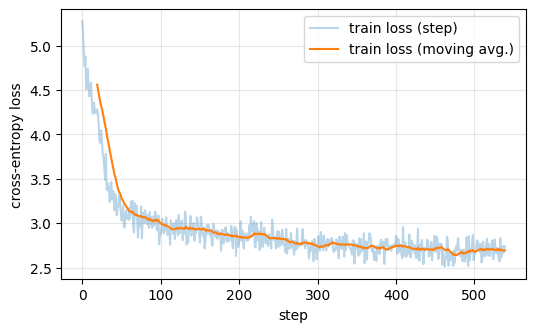

In [16]:
# 学習損失の推移を描く
def smooth(x, k=20):
    return np.convolve(x, np.ones(k) / k, mode="valid")

plt.figure(figsize=(6, 3.5))
plt.plot(hist_mlp, alpha=0.3, label="train loss (step)")
plt.plot(np.arange(len(smooth(hist_mlp))) + 19, smooth(hist_mlp), label="train loss (moving avg.)")
plt.xlabel("step"); plt.ylabel("cross-entropy loss"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 学習後の説明文

同じ評価用画像について、学習前と学習後の出力を並べる

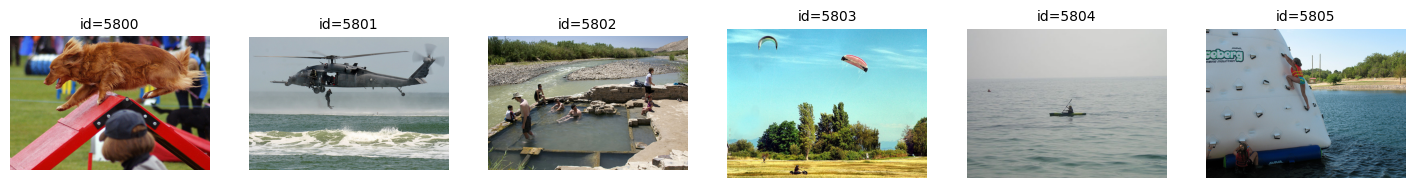

[5800] 学習前: istry
      学習後: A dog is running in a field .
      正解例: A brown dog is doing amazing stunts in the dog show .
[5801] 学習前: The word "logic" is a word that is used in many different ways. It
      学習後: A man is riding a surfboard .
      正解例: A grey helicopter hovering while someone drops in the ocean .
[5802] 学習前: Word Word Word Word Word Word Word Word Word Word Word Word Word Word Word Word Word Word Word Word
      学習後: A boy and a girl are walking along a beach .
      正解例: People in or near water with trees in the background .
[5803] 学習前: Waw Waw Waw Waw Waw Waw Waw Waw Waw Waw
      学習後: A person is jumping off a cliff .
      正解例: A bike in a field and two kites
[5804] 学習前: The word "miracle" is a word that has been used in the Bible for
      学習後: A man is riding a surfboard on a surfboard .
      正解例: a kayaker kayaks through the water .
[5805] 学習前: muh muh muh muh muh muh muh muh muh muh
      学習後: A girl is swimming in the water .
      正解例: A girl climbs an inf

In [17]:
# 学習前後の説明文を、画像と並べて表示する
after_caps = generate_caption(proj_mlp, show_ids)
fig, axes = plt.subplots(1, len(show_ids), figsize=(18, 3.2))
for ax, i in zip(axes, show_ids):
    ax.imshow(ds[i]["image"]); ax.set_title(f"id={i}", fontsize=10); ax.axis("off")
plt.show()
for i, b, a in zip(show_ids, before_caps, after_caps):
    print(f"[{i}] 学習前: {b}\n      学習後: {a}\n      正解例: {caps[i][0]}")

In [18]:
# 学習後の単語の一致率を、入れ替え対照と比べる
ov_after = word_overlap(proj_mlp)
ov_after_shuf = word_overlap(proj_mlp, shift=37)
print(f"学習前の一致率（正しい画像）: {ov_before:.3f}")
print(f"学習後の一致率（正しい画像）: {ov_after:.3f}")
print(f"学習後の一致率（別の画像）  : {ov_after_shuf:.3f}")

学習前の一致率（正しい画像）: 0.014
学習後の一致率（正しい画像）: 0.354
学習後の一致率（別の画像）  : 0.115


## 結果の読み方

検証時の実行（EPOCHS = 6）では、次の結果になった（乱数や環境によって数値は多少変わる）

| | 学習前 | 学習後 |
| --- | --- | --- |
| 評価損失 | 5.22 | 2.72 |
| 単語の一致率（正しい画像） | 0.014 | 0.384 |
| 単語の一致率（別の画像） | 0.004 | 0.121 |

- 学習前は「istry」「Word Word Word ...」のような、画像と無関係な出力であった
- 学習後は「A dog is running in a field .」のように、Flickr8kの説明文と同じ型の短い文になった
  - 犬の画像には dog、水辺の画像には beach や water が出ており、**画像に関係する語**が現れている
- 正しい画像との一致率（0.384）は、別の画像との一致率（0.121）の約3倍である
  - 別の画像との一致率が0にならないのは、man や people のようなどの画像にもよく現れる語があるためである
  - 2つの差が、モデルが画像トークンから情報を読み取っている証拠である
- 学習したのは約78万個のパラメータだけで、画像エンコーダも言語モデルも一切変えていない
- 損失の図を見ると、最初の約100ステップで急に下がり、その後はゆっくり下がり続けている
  - 「説明文らしい短い文を書く」ことは早い段階で身につき、その後に「画像ごとに書き分ける」ことを少しずつ学んでいると解釈できる

一方で、限界もはっきり見える

- 場面の大まかな種類（犬、水辺、人）は合うが、細部は誤る
  - ヘリコプターの画像やカヤックの画像に対して surfboard と答えている
  - 「水辺で人が何かをしている」という大まかな特徴から、学習データに多い語を選んでいると考えられる
- 画像に写っていないものを、もっともらしく書いてしまう
  - VLMのハルシネーション（hallucination）の最も単純な例である
- 原因は、データが6000枚と少ないこと、言語モデルが小さいこと、画像エンコーダの解像度が低いこと（224×224を49個に要約）である
  - 実用のVLMは、この3つをそれぞれ桁違いに大きくしている

## 画像トークンは「単語」なのか

プロジェクタは、パッチ特徴を単語埋め込みと同じ576次元の空間に写す
では、学習後の画像トークンは、既存の単語の埋め込みのどれかに近いのだろうか

次のセルで、評価用画像1枚の画像トークン49個について、次の2つを調べる

- コサイン類似度が最も高い語彙中のトークン
- ベクトルの長さ（ノルム）を、単語埋め込みの平均と比べたもの

In [19]:
# 学習後の画像トークンに最も近い単語と、ノルムの比較
with torch.no_grad():
    z = proj_mlp(patch_feats[show_ids[2]:show_ids[2] + 1].float())[0]          # (49, 576)
    W = E.weight
    nearest = (F.normalize(z, dim=-1) @ F.normalize(W, dim=-1).T).argmax(dim=-1)
    best_sim = (F.normalize(z, dim=-1) @ F.normalize(W, dim=-1).T).max(dim=-1).values

words, counts = np.unique([tok.decode(int(t)) for t in nearest], return_counts=True)
print("最も近いトークンの内訳:", sorted(zip(counts.tolist(), words.tolist()), reverse=True)[:8])
print(f"最も近いトークンとのコサイン類似度の平均: {best_sim.mean().item():.3f}")
print(f"画像トークンのノルムの平均: {z.norm(dim=-1).mean().item():.2f}")
print(f"単語埋め込みのノルムの平均: {W.norm(dim=-1).mean().item():.2f}")

最も近いトークンの内訳: [(40, ' larger'), (4, ' bigger'), (3, ' strange'), (1, ' thicker'), (1, ' Municipal')]
最も近いトークンとのコサイン類似度の平均: 0.193
画像トークンのノルムの平均: 15.24
単語埋め込みのノルムの平均: 3.18


## 結果の読み方

検証時の実行では、次の結果になった

- 49個の画像トークンのうち41個で、最も近いトークンが同じ1語（` larger`）になった
  - 画像の内容（川辺の水場にいる人々）とは関係のない語である
- 最も近いトークンとのコサイン類似度は、平均で0.19と低い
- 画像トークンのノルムは平均15.3で、単語埋め込みの平均3.2の約5倍である

ここからわかるのは、**画像トークンは既存の単語の言い換えではない**ということである

- プロジェクタは「このパッチは dog という単語に相当する」という変換を学習したわけではない
- 単語埋め込みが分布している領域から外れた場所に、言語モデルが続きの文を書くのに役立つベクトルを作っている
  - 学習時の損失は「説明文を正しく予測できるか」だけであり、画像トークンが単語に近いことは求めていない
- 「画像トークンを単語埋め込みと同じ空間に置く」とは、次元を合わせて同じ入力列に並べられるようにするという意味である
  - 意味のうえで単語と1対1に対応させるという意味ではない

- ただし、これは小さなモデルと少ないデータでの1つの観察である
  - 大規模なVLMで画像トークンがどのような表現になっているかは、ここからは断定できない

---

# 問い合わせトークン方式を試す

## 49個を8個に要約する

射影方式では、パッチ49個がそのまま画像トークン49個になった
次に、問い合わせトークン方式で**8個**に要約してみる

仕組みは次のとおりである

1. 学習可能なベクトルを8本用意する（問い合わせトークン）
2. 問い合わせトークンを問い合わせ側（query）、パッチ特徴を参照される側（key、value）として、クロスアテンションを1回かける
   - 各問い合わせトークンは、49個のパッチのうち自分に必要なものを重み付きで集める
3. 集めた結果を小さなMLPで整え、8個の画像トークンとして言語モデルに渡す

<img src="https://class.west.sd.keio.ac.jp/dataai/text/vlm-query-resampler.png" width=700>

上の図では、上の橙色の8本が問い合わせトークン、左の格子が49本のパッチ特徴である
出力は常に8個である

- クロスアテンションの仕組みは `mlsys-text-J-NLP-4-Transformer-full.ipynb` を参照
- BLIP-2のQ-FormerやFlamingoのPerceiver Resamplerは、これを何層も重ねたものである
  - ここでは1層だけの最小版を作る
- 問い合わせトークンは画像によらず同じである
  - 「どんな画像に対しても聞いておきたい8つの質問」を学習していると考えるとよい

In [20]:
# 問い合わせトークン方式のプロジェクタ（クロスアテンション1層の最小版）
class QueryResampler(nn.Module):
    def __init__(self, d_in, d_out, n_query=8, n_head=8):
        super().__init__()
        self.query = nn.Parameter(torch.randn(n_query, d_out) * 0.02)   # 学習可能な問い合わせトークン
        self.inp = nn.Linear(d_in, d_out)                               # パッチ特徴の次元を合わせる
        self.attn = nn.MultiheadAttention(d_out, n_head, batch_first=True)
        self.norm = nn.LayerNorm(d_out)
        self.ff = nn.Sequential(nn.Linear(d_out, d_out * 2), nn.GELU(), nn.Linear(d_out * 2, d_out))

    def forward(self, x):
        kv = self.inp(x)                                                # (B, 49, d_out)
        q = self.query.unsqueeze(0).expand(x.size(0), -1, -1)           # (B, 8, d_out)
        h = q + self.attn(q, kv, kv)[0]                                 # 問い合わせトークンがパッチを参照する
        return h + self.ff(self.norm(h))                                # (B, 8, d_out)

torch.manual_seed(SEED)
proj_q = QueryResampler(D_VIS, D_LM).to(device)
print("パラメータ数:", sum(p.numel() for p in proj_q.parameters()))
print("出力の形:", tuple(proj_q(patch_feats[:2].float()).shape))

パラメータ数: 3106944
出力の形: (2, 8, 576)


`build_prefix`、`caption_loss`、`generate_caption` は、プロジェクタの出力の本数に依存しない書き方にしてある
そのため、プロジェクタを差し替えるだけで同じ学習関数が使える

- 入力列が短くなる（1＋49＋説明文 → 1＋8＋説明文）ので、1ステップの計算も軽くなる

In [21]:
r # 問い合わせトークン方式のプロジェクタを、同じ条件で学習する
random.seed(SEED)
torch.manual_seed(SEED)
hist_q = train_projector(proj_q, EPOCHS)

epoch 1/6  train loss 3.150  val loss 2.998  (44s)
epoch 2/6  train loss 2.911  val loss 2.883  (88s)
epoch 3/6  train loss 2.808  val loss 2.764  (132s)
epoch 4/6  train loss 2.715  val loss 2.707  (176s)
epoch 5/6  train loss 2.672  val loss 2.671  (219s)
epoch 6/6  train loss 2.667  val loss 2.663  (263s)


方式                   トークン数      パラメータ数      評価損失     一致率     別画像
MLP (49 tokens)           49          775296       2.716     0.354     0.115
Query (8 tokens)           8         3106944       2.663     0.417     0.129


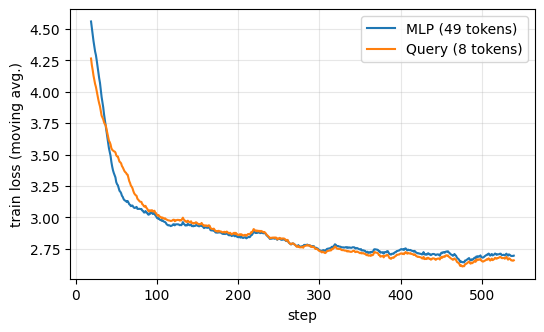

[5800] MLP  : A dog is running in a field .
      Query: A dog is running in a field .
      正解例: A brown dog is doing amazing stunts in the dog show .
[5801] MLP  : A man is riding a surfboard .
      Query: A man is riding a wave .
      正解例: A grey helicopter hovering while someone drops in the ocean .
[5802] MLP  : A boy and a girl are walking along a beach .
      Query: A man is walking along a beach with a boat in the water .
      正解例: People in or near water with trees in the background .
[5803] MLP  : A person is jumping off a cliff .
      Query: A man is riding a skateboard .
      正解例: A bike in a field and two kites
[5804] MLP  : A man is riding a surfboard on a surfboard .
      Query: A man is swimming in the water .
      正解例: a kayaker kayaks through the water .
[5805] MLP  : A girl is swimming in the water .
      Query: A boy is swimming in the water .
      正解例: A girl climbs an inflatable wall over water .


In [22]:
# 2つの方式を比べる
results = {}
for name, proj in [("MLP (49 tokens)", proj_mlp), ("Query (8 tokens)", proj_q)]:
    results[name] = dict(tokens=proj(patch_feats[:1].float()).shape[1],
                         params=sum(p.numel() for p in proj.parameters()),
                         val=val_loss(proj), ov=word_overlap(proj), ov_shuf=word_overlap(proj, shift=37))
print(f"{'方式':<18}{'トークン数':>8}{'パラメータ数':>12}{'評価損失':>10}{'一致率':>8}{'別画像':>8}")
for name, r in results.items():
    print(f"{name:<18}{r['tokens']:>10}{r['params']:>16}{r['val']:>12.3f}{r['ov']:>10.3f}{r['ov_shuf']:>10.3f}")

plt.figure(figsize=(6, 3.5))
plt.plot(np.arange(len(smooth(hist_mlp))) + 19, smooth(hist_mlp), label="MLP (49 tokens)")
plt.plot(np.arange(len(smooth(hist_q))) + 19, smooth(hist_q), label="Query (8 tokens)")
plt.xlabel("step"); plt.ylabel("train loss (moving avg.)"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

for i, a, b in zip(show_ids, generate_caption(proj_mlp, show_ids), generate_caption(proj_q, show_ids)):
    print(f"[{i}] MLP  : {a}\n      Query: {b}\n      正解例: {caps[i][0]}")

## 結果の読み方

検証時の実行では、次の結果になった

| 方式 | 画像トークン数 | プロジェクタのパラメータ数 | 評価損失 | 一致率（正しい画像） | 一致率（別の画像） |
| --- | --- | --- | --- | --- | --- |
| MLP | 49 | 約78万 | 2.717 | 0.384 | 0.121 |
| 問い合わせトークン | 8 | 約311万 | 2.687 | 0.409 | 0.123 |

- 画像トークンを49個から8個に減らしても、説明文の質は落ちなかった
  - 評価損失と一致率は、わずかに問い合わせトークン方式のほうが良い
  - ただし差は小さく、乱数シード1つだけの結果なので、優劣があるとまでは言えない
  - 損失の図でも、学習の最初はMLPのほうが速く下がるが、100ステップ以降は2つの曲線がほぼ重なっている
- 言語モデルへの入力が短くなるので、1エポックの学習時間は短くなった
- その代わり、プロジェクタ自体のパラメータ数は約4倍になっている
  - 接続部で手間をかけて要約し、LLM側の負担を減らす、という分担である

なぜ8個で足りたのかは、課題の性質から説明できる

- 1文の説明文に必要なのは「何が、どこで、何をしているか」という大まかな情報である
  - 49個のパッチには重複した情報が多く、8本のベクトルに要約しても失われるものが少ない
- 文字を読む、小さな物体を数える、位置を答える、といった課題では、場所ごとの細かい情報が必要になる
  - 要約によって落ちる情報が問題になるのは、こうした課題である
  - 接続方式の比較表で「細部の情報が落ちやすい」と書いたのは、この点を指している
  - 本テキストの実験では、その差までは確かめていない

---

# 2段階の学習

## 位置合わせと指示チューニング

ここまでの学習で、自作VLMは画像の説明文を書けるようになった
しかし、「この画像に犬はいるか」と質問しても答えられない

- 言語モデルは説明文の続きを書くことしか学習していない
- 画像トークンの後に質問を置くという入力の形を、一度も見たことがない

LLaVA（Liu et al., 2023）は、学習を2段階に分けることでこれを解決した

| | 第1段階: 特徴の位置合わせ | 第2段階: 指示チューニング |
| --- | --- | --- |
| 英語名 | feature alignment pre-training | visual instruction tuning |
| 目的 | 画像トークンをLLMが読める形にする | 画像についての指示や質問に答えられるようにする |
| データ | 画像と説明文の対 | 画像・指示（質問）・応答の組 |
| 学習する部品 | プロジェクタのみ | プロジェクタ ＋ LLM |
| 凍結する部品 | 画像エンコーダ、LLM | 画像エンコーダ |
| LLaVAでの規模 | 約59.5万対 | 約15.8万件 |

<img src="https://class.west.sd.keio.ac.jp/dataai/text/vlm-two-stage.png" width=750>

上の図で、橙色が各段階で学習する部品である
第2段階ではLLMも学習の対象に加わる

- 本テキストでここまで行ったのは、**第1段階だけ**である
- 第1段階でLLMを凍結するのは、乱数で初期化されたプロジェクタから流れてくる大きな勾配で、LLMの能力を壊さないためである
  - 先にプロジェクタだけを育て、画像トークンが意味を持ってからLLMを動かす
- 第2段階の指示データは、人手で作ると高価である
  - LLaVAは、画像の説明文と物体の位置情報を**テキストだけのLLM**に渡し、会話形式の質問と応答を生成させた
  - 画像を見ないLLMにデータを作らせた点が工夫である
- 指示チューニングそのものの仕組み（応答部分だけに損失をかける、LoRAで一部だけを更新する）は `mlsys-text-J-NLP-8-LLM調整.ipynb` を参照
- その後のVLMでは、LLM全体の代わりにLoRAで一部だけを更新したり、高解像度に対応するため画像エンコーダも更新したりと、段階の切り方に多くの変種がある

## 小さな指示チューニングを試す

第2段階の効果を、小さな実験で確かめる

- 説明文から「はい／いいえ」で答える質問を自動で作る
  - 例: 説明文5文のどれかに dog が含まれていれば、「Is there a dog in the image?」の答えは yes とする
  - 説明文に書かれていないだけで実際には写っている場合もあるので、正解にはある程度の雑音が含まれる
- 入力列は `[BOS ; 画像トークン ; 質問文]` とし、最後の位置で次のトークンが ` yes` か ` no` かを予測させる
- 第1段階で学習したMLPプロジェクタから始める

In [23]:
# 説明文から「はい／いいえ」の質問と正解を自動で作る
KEYS = {  # 質問に入れる語句: その語句があるとみなす単語
    "a dog": ["dog", "dogs", "puppy"],
    "a man": ["man", "men"],
    "a woman": ["woman", "women", "lady"],
    "a child": ["child", "children", "boy", "boys", "girl", "girls", "kid", "kids", "baby", "toddler"],
    "water": ["water", "pool", "lake", "ocean", "river", "sea"],
    "a ball": ["ball", "football", "basketball", "soccer"],
    "snow": ["snow", "snowy"],
    "a beach": ["beach", "sand"],
    "a bike": ["bike", "bicycle", "bikes", "bicycles", "motorcycle"],
    "grass": ["grass", "grassy", "field", "lawn"],
}
cap_words = [set(w for c in cs for w in re.findall(r"[a-z]+", c.lower())) for cs in caps]
qa_label = {k: torch.tensor([any(w in cw for w in ws) for cw in cap_words]) for k, ws in KEYS.items()}

for k in KEYS:
    print(f"{k:<10} yes の割合（学習用）: {qa_label[k][:NT].float().mean().item():.3f}")

YES_ID = tok(" yes").input_ids[-1]
NO_ID = tok(" no").input_ids[-1]
print("yes / no のトークン:", repr(tok.decode(YES_ID)), repr(tok.decode(NO_ID)))

a dog      yes の割合（学習用）: 0.255
a man      yes の割合（学習用）: 0.342
a woman    yes の割合（学習用）: 0.178
a child    yes の割合（学習用）: 0.363
water      yes の割合（学習用）: 0.166
a ball     yes の割合（学習用）: 0.090
snow       yes の割合（学習用）: 0.073
a beach    yes の割合（学習用）: 0.059
a bike     yes の割合（学習用）: 0.055
grass      yes の割合（学習用）: 0.162
yes / no のトークン: ' yes' ' no'


In [24]:
# 質問応答の入力列を作り、最後の位置のロジットを返す
def qa_logits(proj, model, idx, key):
    prefix = build_prefix(proj, idx)
    q = tok(f" Question: Is there {key} in the image? Answer:", return_tensors="pt").input_ids.to(device)
    q = model.get_input_embeddings()(q).expand(len(idx), -1, -1)
    # 必要なのは最後の位置の予測だけなので、Transformer本体の出力の最後の位置だけを語彙への写像（lm_head）にかける
    # （全位置のロジットを作ると、200枚なら 200 x 62 x 49152 の float32 で約2.3GB になり、T4ではメモリ不足になる）
    h = model.model(inputs_embeds=torch.cat([prefix, q], dim=1)).last_hidden_state[:, -1]   # (B, D_LM)
    return model.lm_head(h)                                                                 # (B, 語彙数)

@torch.no_grad()
def qa_eval(proj, model, shuffle_images=False, batch_size=50):
    # 評価用200枚 x 10種類の質問で、yes と no それぞれの正解率を測る（メモリ節約のため50枚ずつ処理する）
    img_ids = val_ids[37:] + val_ids[:37] if shuffle_images else val_ids   # 入れ替え対照: 別の画像を見せる
    hit = {True: 0, False: 0}
    cnt = {True: 0, False: 0}
    for key in KEYS:
        lg = torch.cat([qa_logits(proj, model, img_ids[i:i + batch_size], key)
                        for i in range(0, len(img_ids), batch_size)])
        pred = (lg[:, YES_ID] > lg[:, NO_ID]).cpu()
        gold = qa_label[key][val_ids]
        for g in (True, False):
            hit[g] += int((pred[gold == g] == g).sum())
            cnt[g] += int((gold == g).sum())
    rec_yes, rec_no = hit[True] / cnt[True], hit[False] / cnt[False]
    return rec_yes, rec_no, (rec_yes + rec_no) / 2

r = qa_eval(proj_mlp, lm)
print(f"第1段階のみ: yesの正解率 {r[0]:.3f} / noの正解率 {r[1]:.3f} / 平均 {r[2]:.3f}")

第1段階のみ: yesの正解率 1.000 / noの正解率 0.000 / 平均 0.500


## 評価の読み方

- yes が正解の質問と no が正解の質問では数が大きく違う（ほとんどの質問は no が正解である）
  - 全体の正解率で測ると、常に no と答えるだけで高い値が出てしまう
  - そこで yes と no の正解率を別々に測り、その**平均**を見る
  - 何も見ずに答えると、平均は0.5付近になる
- 第1段階のみのモデルは、平均が0.5に近い
  - 画像トークンは読めているはずだが、質問に答えるという形式を知らないためである

次のセルで指示チューニングを行う

- 1ステップごとに質問を5種類選び、それぞれ yes の画像と no の画像を8枚ずつ取る（偏りを避けるため）
  - 1ステップで1種類の質問だけを学習させると、質問ごとに勾配の向きが変わり、学習が進みにくかった
- 次の2通りを同じステップ数で比べる
  - **プロジェクタのみ学習**（言語モデルは凍結、学習率 $10^{-3}$）
  - **プロジェクタと言語モデルを学習**（学習率はプロジェクタ $3 \times 10^{-4}$、言語モデル $2 \times 10^{-4}$）
- 言語モデルは複製を作って学習させ、元の凍結した言語モデルは残しておく
- 各300ステップで、T4での所要時間の目安は合わせて10〜15分である
  - 時間を短くしたい場合は `S2_STEPS` を小さくする
- GPUメモリ（T4は約15GB）に収めるための工夫を3つ入れてある
  - `qa_logits` は最後の位置だけを語彙に写像する
    - 全位置のロジットを作ると、評価用200枚では 200 × 62 × 49152 の float32 で約2.3GBになり、それだけでメモリ不足になる
    - 評価は50枚ずつに分けて行う
  - 言語モデルを学習すると、重み・勾配・AdamWの状態（2つ）で言語モデル4個分のメモリを使う
    - 学習が終わったら勾配と最適化器を解放し、言語モデルを凍結に戻す（`instruction_tune` の末尾）
    - 凍結したまま使う場合は複製を作らない
  - 1ステップ内の5種類の質問は、損失を合計してから逆伝播するのではなく、1種類ずつ逆伝播して勾配を足し合わせる（**勾配累積**）
    - 得られる勾配は損失の和の勾配と同じだが、計算グラフを1種類分しか保持しないので、活性のメモリが約1/5になる
    - 大きなバッチをメモリに収めるための定石で、LLMの学習で広く使われている

In [25]:
# 第2段階（指示チューニング）を行う関数
def instruction_tune(train_lm, steps, lr_proj, lr_lm=0.0, n_keys=5, n_each=8):
    torch.manual_seed(SEED)
    rng = np.random.RandomState(SEED)
    proj = copy.deepcopy(proj_mlp)          # 第1段階の結果から始める
    model = copy.deepcopy(lm) if train_lm else lm   # 言語モデルを学習するときだけ複製する（凍結なら元のものをそのまま使う）
    groups = [{"params": proj.parameters(), "lr": lr_proj}]
    if train_lm:
        for p in model.parameters():
            p.requires_grad_(True)
        groups.append({"params": model.parameters(), "lr": lr_lm})
    opt = torch.optim.AdamW(groups)
    keys = list(KEYS)
    pools = {k: (torch.where(qa_label[k][:NT])[0].numpy(), torch.where(~qa_label[k][:NT])[0].numpy()) for k in keys}
    target = torch.tensor([YES_ID] * n_each + [NO_ID] * n_each, device=device)
    history = []
    t0 = time.time()
    for step in range(steps):
        opt.zero_grad()
        loss = 0.0
        for key in rng.choice(keys, n_keys, replace=False):
            yes_pool, no_pool = pools[key]
            idx = np.concatenate([rng.choice(yes_pool, n_each), rng.choice(no_pool, n_each)]).tolist()
            l = F.cross_entropy(qa_logits(proj, model, idx, key), target) / n_keys
            l.backward()        # 質問の種類ごとに逆伝播し、勾配を足し合わせる（勾配累積）
            loss += l.item()    # 5種類分の計算グラフを同時に持たないので、活性のメモリが1/5で済む
        opt.step()              # 足し合わせた勾配（= 5種類の損失の和の勾配）で1回更新する
        history.append(loss)
        if (step + 1) % 100 == 0:
            print(f"step {step+1}  loss {np.mean(history[-50:]):.3f}  ({time.time()-t0:.0f}s)")
    # 学習が終わったら、勾配と最適化器の状態をGPUから解放する
    # （言語モデルを学習した場合、重み・勾配・AdamWの状態2つで言語モデル4個分のメモリを占めている）
    opt.zero_grad(set_to_none=True)
    del opt
    for p in model.parameters():
        p.requires_grad_(False)
    model.eval()
    if device.type == "cuda":
        torch.cuda.empty_cache()
    return proj, model, history

--- プロジェクタのみ学習（言語モデルは凍結）
step 100  loss 0.643  (91s)
step 200  loss 0.571  (182s)
step 300  loss 0.471  (273s)
--- プロジェクタと言語モデルを学習
step 100  loss 0.669  (133s)
step 200  loss 0.459  (267s)
step 300  loss 0.348  (400s)
yes 1.000 / no 0.000 / 平均 0.500  第1段階のみ
yes 0.905 / no 0.550 / 平均 0.728  第2段階（プロジェクタのみ）
yes 0.933 / no 0.766 / 平均 0.850  第2段階（プロジェクタ＋言語モデル）
yes 0.401 / no 0.650 / 平均 0.525  同上、別の画像を見せた場合
GPUメモリの最大使用量: 8.9 GiB（T4は約15 GiB）


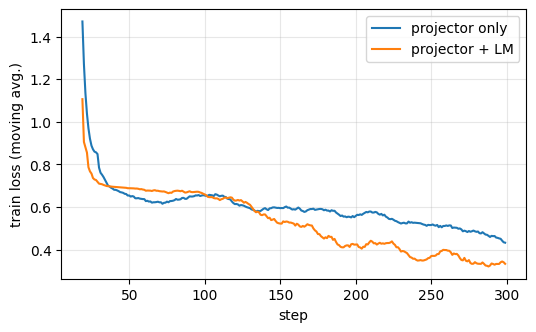

In [26]:
# 2通りの指示チューニングを実行して比べる
S2_STEPS = 300
print("--- プロジェクタのみ学習（言語モデルは凍結）")
proj_s2a, lm_s2a, hist_s2a = instruction_tune(train_lm=False, steps=S2_STEPS, lr_proj=1e-3)
print("--- プロジェクタと言語モデルを学習")
proj_s2, lm_s2, hist_s2 = instruction_tune(train_lm=True, steps=S2_STEPS, lr_proj=3e-4, lr_lm=2e-4)

rows = [("第1段階のみ", qa_eval(proj_mlp, lm)),
        ("第2段階（プロジェクタのみ）", qa_eval(proj_s2a, lm_s2a)),
        ("第2段階（プロジェクタ＋言語モデル）", qa_eval(proj_s2, lm_s2)),
        ("同上、別の画像を見せた場合", qa_eval(proj_s2, lm_s2, shuffle_images=True))]
for name, r in rows:
    print(f"yes {r[0]:.3f} / no {r[1]:.3f} / 平均 {r[2]:.3f}  {name}")
if device.type == "cuda":
    print(f"GPUメモリの最大使用量: {torch.cuda.max_memory_allocated()/2**30:.1f} GiB（T4は約15 GiB）")

plt.figure(figsize=(6, 3.5))
plt.plot(np.arange(len(smooth(hist_s2a))) + 19, smooth(hist_s2a), label="projector only")
plt.plot(np.arange(len(smooth(hist_s2))) + 19, smooth(hist_s2), label="projector + LM")
plt.xlabel("step"); plt.ylabel("train loss (moving avg.)"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

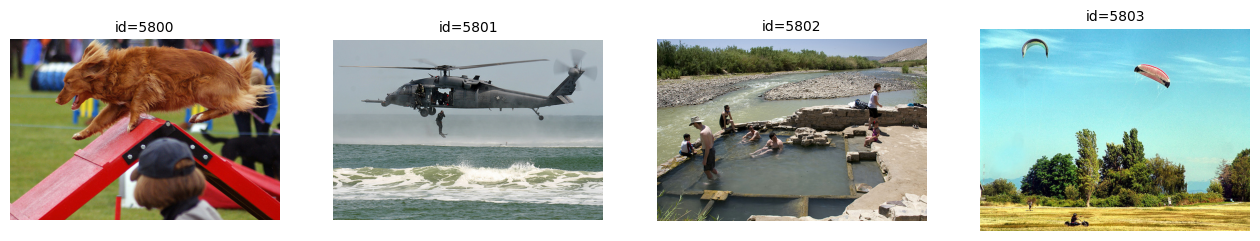

Is there a dog in the image?  予測: ['yes', 'no', 'no', 'no']  正解: ['yes', 'no', 'no', 'no']
Is there a child in the image?  予測: ['no', 'no', 'yes', 'yes']  正解: ['no', 'no', 'no', 'yes']
Is there water in the image?  予測: ['no', 'yes', 'yes', 'yes']  正解: ['no', 'yes', 'yes', 'no']
Is there a ball in the image?  予測: ['yes', 'no', 'no', 'no']  正解: ['no', 'no', 'no', 'no']


In [27]:
# 評価用画像に対する質問応答の例を表示する
@torch.no_grad()
def answer_yes_no(idx, key):
    lg = qa_logits(proj_s2, lm_s2, idx, key)
    return ["yes" if a > b else "no" for a, b in zip(lg[:, YES_ID].tolist(), lg[:, NO_ID].tolist())]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, i in zip(axes, val_ids[:4]):
    ax.imshow(ds[i]["image"]); ax.set_title(f"id={i}", fontsize=10); ax.axis("off")
plt.show()
for key in ["a dog", "a child", "water", "a ball"]:
    ans = answer_yes_no(val_ids[:4], key)
    gold = ["yes" if g else "no" for g in qa_label[key][val_ids[:4]].tolist()]
    print(f"Is there {key} in the image?  予測: {ans}  正解: {gold}")

In [28]:
# 指示チューニング後の言語モデルに、説明文を書かせてみる
for i, a, b in zip(show_ids[:4], generate_caption(proj_mlp, show_ids[:4]),
                   generate_caption(proj_s2, show_ids[:4], model=lm_s2)):
    print(f"[{i}] 第1段階のモデル: {a}\n      第2段階のモデル: {b!r}")

[5800] 第1段階のモデル: A dog is running in a field .
      第2段階のモデル: 'no no no no no no no no no no no no no no no no no no no no'
[5801] 第1段階のモデル: A man is riding a surfboard .
      第2段階のモデル: 'no no no no no no no no no no no no no no no no no no no no'
[5802] 第1段階のモデル: A boy and a girl are walking along a beach .
      第2段階のモデル: 'no no no no no no no no no no no no no no no no no no no no'
[5803] 第1段階のモデル: A person is jumping off a cliff .
      第2段階のモデル: 'no no no no no no no no no no no no no no no no no no no no'


## 結果の読み方

検証時の実行（S2_STEPS = 300）では、次の結果になった

| モデル | yesの正解率 | noの正解率 | 平均 |
| --- | --- | --- | --- |
| 第1段階のみ | 1.000 | 0.000 | 0.500 |
| 第2段階（プロジェクタのみ学習） | 0.894 | 0.539 | 0.716 |
| 第2段階（プロジェクタ＋言語モデルを学習） | 0.925 | 0.804 | 0.864 |
| 同上、別の画像を見せた場合 | 0.398 | 0.689 | 0.543 |

- 第1段階のみのモデルは、すべての質問に yes と答えた
  - 質問の形式を知らないので、画像を見て答えを変えるということができない
- プロジェクタだけを学習しても、平均は0.72まで上がる
  - 画像トークンの作り方を変えるだけでも、ある程度は質問に対応できる
- **言語モデルも学習させると0.86まで上がる**
  - 損失の図では、最初の100ステップほどは2つの曲線にほとんど差がなく、その後、言語モデルも学習させたほうだけが下がり続ける
  - 質問を読み、画像トークンの中から該当する情報を探し、yes か no を出す、という新しい動作は、言語モデル側を変えたほうが身につきやすい
  - これが、第2段階でLLMを学習の対象に加える理由である
- 別の画像を見せると平均は0.54に落ち、でたらめに答えた場合の0.5に近づく
  - 質問文だけから答えを当てているのではなく、画像を見て答えていることがわかる
- 質問応答の例を見ると、誤りも残っている
  - 正解を説明文から機械的に作ったことによる雑音と、モデルの小ささの両方が原因である

最後のセルの出力は重要である

- 指示チューニング後の言語モデルに説明文を書かせると、「no no no ...」や「yes yes yes ...」しか出なくなった
- yes か no を答える課題**だけ**で言語モデルを更新したため、元の文章を書く能力が失われた
  - **破滅的忘却**（catastrophic forgetting）と呼ばれる現象である
- 実際の指示チューニングでは、これを避けるために次のことを行う
  - 説明、質問応答、文字の読み取り、会話など、多様な課題を混ぜて学習する
  - テキストだけの指示データも混ぜて、元の言語能力を保つ
  - 学習率を小さくする、LoRAのように更新する範囲を限定する
- 指示チューニング、LoRA、破滅的忘却は、テキストのLLMを対象に `mlsys-text-J-NLP-8-LLM調整.ipynb` で詳しく扱っている

ここでの実験は、はい／いいえの10種類の質問だけを扱う小さなものである
実用のVLMの第2段階は、数十万〜数百万件の多様な指示データで行われる

---

# 解像度・画像トークン数・計算量

## 画像トークンはいくつになるか

射影方式では、画像トークンの数はパッチの数で決まる

$$
N_{\text{img}} = \left(\frac{\text{解像度}}{\text{パッチの一辺}}\right)^2
$$

- 解像度を2倍にすると、トークン数は**4倍**になる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/vlm-resolution-tokens.png" width=700>

上の図は、パッチの大きさを変えずに画像の一辺を2倍、4倍にした場合である
アテンションの計算量はトークン数の2乗で増えるので、さらに急に大きくなる（次の節で扱う）

- 細かい文字や小さな物体を読むには高い解像度が必要である
  - 224×224に縮小された書類の画像では、人間でも小さな文字は読めない

In [29]:
# 解像度とパッチの大きさから、画像トークン数を計算する
configs = [("ViT-B/32", 224, 32), ("ViT-B/16", 224, 16), ("ViT-L/14", 224, 14), ("ViT-L/14", 336, 14),
           ("patch 14", 448, 14), ("patch 14", 896, 14), ("patch 14", 1344, 14)]
print(f"{'encoder':<10}{'resolution':>12}{'patch':>7}{'tokens':>8}{'relative attention cost':>26}")
base = (224 // 32) ** 2
for name, res, p in configs:
    n = (res // p) ** 2
    print(f"{name:<10}{res:>8}x{res:<4}{p:>6}{n:>8}{(n / base) ** 2:>22.0f}x")

encoder     resolution  patch  tokens   relative attention cost
ViT-B/32       224x224     32      49                     1x
ViT-B/16       224x224     16     196                    16x
ViT-L/14       224x224     14     256                    27x
ViT-L/14       336x336     14     576                   138x
patch 14       448x448     14    1024                   437x
patch 14       896x896     14    4096                  6988x
patch 14      1344x1344    14    9216                 35375x


## トークン数と計算量

Transformerの自己アテンションは、すべてのトークンの組を計算するので、計算量は列の長さ $L$ に対して $O(L^2)$ で増える（全結合層の部分は $O(L)$ である）

- 上の表の右端は、トークン数の2乗を、本テキストの設定（49個）を1として表したものである
- 336×336のViT-L/14（LLaVA-1.5の設定）で576個になる
- 1344×1344では9216個になり、質問文が数十トークンであっても、入力のほとんどが画像になる

LLMにとって、画像トークンは文章のトークンと同じだけコストがかかる

- 計算時間が延びる
- コンテキスト長を消費する（複数の画像や長い会話を入れにくくなる）
- APIとして提供されるVLMでは、画像もトークン数に換算して課金される

次のセルで、言語モデルに与える画像トークンの数を変えて、処理時間を実測する

image tokens     8:    45.7 ms
image tokens    49:    41.0 ms
image tokens   196:    55.7 ms
image tokens   576:    86.7 ms
image tokens  1024:   180.2 ms
image tokens  2304:   617.0 ms


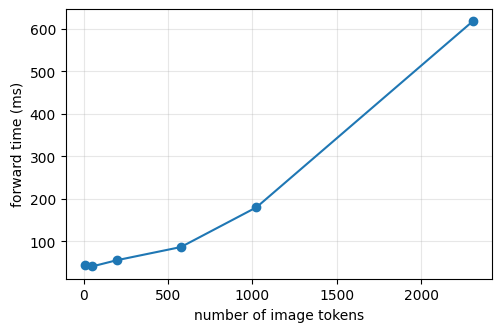

In [30]:
# 画像トークンの数を変えて、言語モデルの順伝播の時間を測る
@torch.no_grad()
def time_forward(n_img, n_text=32, repeat=5):
    x = torch.randn(1, n_img + n_text, D_LM, device=device) * 0.1   # 中身は乱数でよい（時間だけを測る）
    lm(inputs_embeds=x)                                              # 1回目は準備に時間がかかるので捨てる
    if device.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(repeat):
        lm(inputs_embeds=x)
    if device.type == "cuda":
        torch.cuda.synchronize()
    return (time.time() - t0) / repeat * 1000

n_list = [8, 49, 196, 576, 1024, 2304]
ms = [time_forward(n) for n in n_list]
for n, t in zip(n_list, ms):
    print(f"image tokens {n:>5}: {t:7.1f} ms")

plt.figure(figsize=(5.5, 3.5))
plt.plot(n_list, ms, "o-")
plt.xlabel("number of image tokens"); plt.ylabel("forward time (ms)"); plt.grid(alpha=0.3)
plt.show()

## 結果の読み方と、トークン数を抑える工夫

- 画像トークンが増えると、処理時間が増える
  - 検証時の実行では、8個から2304個に増やすと、時間は数倍〜10倍近くになった
  - トークン数が数百倍になっても時間が数百倍にならないのは、GPUが並列に処理するためである
  - 測定値はGPUの種類や混み具合で変わるので、絶対値ではなく増え方を見る
- ここで測ったのは順伝播1回分である
  - 文章の生成では、出力する1トークンごとに計算が必要になる
  - 過去の計算結果を再利用する仕組み（KVキャッシュ）を使っても、各ステップで全画像トークンへのアテンションを計算する
  - プロンプト全体を処理する段階（prefill）と1トークンずつ出力する段階（decode）の違いは `mlsys-text-Q-推論サービング.ipynb` を参照
  - 画像トークンが増えると、主にprefillの時間が延びる

解像度を上げたいがトークン数は抑えたい、という矛盾に対して、次のような工夫が使われる

| 工夫 | 内容 | 例 |
| --- | --- | --- |
| パッチの統合 | 隣り合う $2 \times 2$ のパッチ特徴を1つにまとめてから射影する（トークン数が1/4になる） | Qwen2-VL |
| 問い合わせトークン | 固定の少数に要約する（前章で実装した方式） | BLIP-2 |
| タイル分割 | 大きな画像を複数のタイルに切り、縮小した全体像と合わせて入力する | LLaVA-NeXT など |
| 可変解像度 | 画像の大きさと縦横比に応じて、トークン数を変える | Qwen2-VL |
| 解像度の上限設定 | 利用者が画素数の上限を指定して、精度と速度を選ぶ | 多くのVLM |

<img src="https://class.west.sd.keio.ac.jp/dataai/text/vlm-token-reduction.png" width=750>

上の図の左がパッチの統合、右がタイル分割である

- タイル分割では、全体像（何が写っているか）とタイル（細部）の両方を入力する
  - 画像エンコーダが学習した解像度（例: 336×336）を変えずに、高解像度の画像を扱える
- どの工夫も「必要な情報を、できるだけ少ないトークンで渡す」ことを狙っている
- 解像度を下げると何が起きるかは、次の章で実際のVLMを使って確かめる

---

# 公開されている小型VLMを動かす

## Qwen2-VL-2B

自作のVLMは仕組みを理解するための最小版で、実用にはならない
ここからは、公開されている小型VLMである**Qwen2-VL-2B-Instruct**（Wang et al., 2024、約22億パラメータ、Apache 2.0ライセンス）を動かす

構造は、これまで見てきたものと同じ3部品である

| 部品 | Qwen2-VL-2B | 自作VLM |
| --- | --- | --- |
| 画像エンコーダ | ViT（パッチの一辺14画素、可変解像度） | CLIP ViT-B/32（224×224固定） |
| 接続部 | 隣り合う $2 \times 2$ のパッチをまとめてMLPで射影 | 2層MLP |
| LLM | 約15億パラメータのデコーダ | SmolLM2-135M |
| 画像1枚のトークン数 | 画像の大きさに応じて変わる（28×28画素あたり1個） | 49個で固定 |
| 学習 | 大規模データで多段階に学習、指示チューニング済み | 説明文6000枚分で位置合わせのみ |

- モデルの取得（約4.4GB）に1〜2分かかる
- 半精度（float16）で読み込み、GPUメモリは5GB程度を使う
- T4のメモリが足りない場合や、より軽いモデルを試したい場合は、`VLM_ID` を `"HuggingFaceTB/SmolVLM-500M-Instruct"`（約5億パラメータ）に変えても、以降のセルは同じコードで動く
  - ただし回答の内容は変わる

In [31]:
# 公開されている小型VLMを読み込む
VLM_ID = "Qwen/Qwen2-VL-2B-Instruct"   # 軽量版: "HuggingFaceTB/SmolVLM-500M-Instruct"
vproc = AutoProcessor.from_pretrained(VLM_ID)
vlm = AutoModelForImageTextToText.from_pretrained(VLM_ID)
vlm = (vlm.half() if device.type == "cuda" else vlm.float()).to(device).eval()
print(f"パラメータ数: {sum(p.numel() for p in vlm.parameters())/1e9:.2f}B")

preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

パラメータ数: 2.21B


## 質問する関数

VLMへの入力は、チャット形式のメッセージである

- 利用者の発言（`role: user`）の中に、画像とテキストを並べて入れる
- `apply_chat_template` が、これをモデルごとの決まった形式のトークン列に変換する
  - 画像は「ここに画像トークンが入る」という目印のトークンに置き換えられ、モデルの内部で画像トークンに差し替えられる
  - 自作VLMで `[BOS ; 画像トークン ; テキスト]` を手で連結したのと同じことを、ライブラリが行っている

<img src="https://class.west.sd.keio.ac.jp/dataai/text/vlm-chat-input.png" width=750>

上の図の橙色が画像の目印で、この位置がモデルの内部で画像トークンに差し替えられる

関数 `ask` は、回答と**入力トークン数**（画像トークンと質問文の合計）を返す
- 入力トークン数を見れば、その画像が何トークンとして扱われたかがわかる

In [32]:
# 画像（複数可）と質問を渡して、回答と入力トークン数を返す関数
@torch.no_grad()
def ask(images, question, max_new_tokens=80):
    content = [{"type": "image", "image": im} for im in images] + [{"type": "text", "text": question}]
    inputs = vproc.apply_chat_template([{"role": "user", "content": content}], add_generation_prompt=True,
                                       tokenize=True, return_dict=True, return_tensors="pt").to(device)
    if device.type == "cuda":   # 画素値をモデルと同じ半精度にそろえる
        inputs = {k: (v.half() if v.is_floating_point() else v) for k, v in inputs.items()}
    n_in = inputs["input_ids"].shape[1]
    out = vlm.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    answer = vproc.batch_decode(out[:, n_in:], skip_special_tokens=True)[0].strip()
    return answer, n_in

def show_images(images, size=3.5):
    fig, axes = plt.subplots(1, len(images), figsize=(size * len(images), size))
    for ax, im in zip(np.atleast_1d(axes), images):
        ax.imshow(im); ax.axis("off")
    plt.show()

## 写真への質問応答

まず、評価用の写真について質問する

- 自作VLMと同じ画像を使うので、説明の詳しさを比べることができる
- 日本語の質問も試す

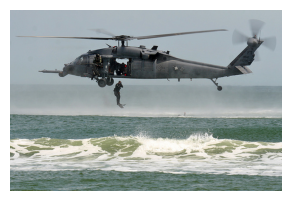

Q: Describe this image in one sentence.
A: A military helicopter is flying over the ocean, with a person water skiing behind it.   [入力 244 トークン]

Q: What is the person wearing?
A: The person in the image is wearing a wet suit.   [入力 243 トークン]

Q: この画像に写っているものを日本語で1文で説明してください
A: この画像には、ヘリコプターが海に浮かんでいる様子が写っています。ヘリコプターの前方には、水上スキーヤーがいる様子が見えます。   [入力 253 トークン]

自作VLMの出力: A man is riding a surfboard .


In [33]:
# 写真について質問する
photo = ds[val_ids[1]]["image"]
show_images([photo])
for q in ["Describe this image in one sentence.",
          "What is the person wearing?",
          "この画像に写っているものを日本語で1文で説明してください"]:
    a, n = ask([photo], q)
    print(f"Q: {q}\nA: {a}   [入力 {n} トークン]\n")
print("自作VLMの出力:", generate_caption(proj_mlp, [val_ids[1]])[0])

## 結果の読み方

検証時の実行では、次のような回答になった

- 英語の質問には「軍用ヘリコプターが海の上を飛んでいる」「ウェットスーツを着ている」という内容の回答が返った
  - 自作VLMの「A man is riding a surfboard .」と比べると、ヘリコプターや服装といった細部まで言及している
- 日本語で質問すると、日本語で答える
  - LLMが多言語で学習されているためで、画像エンコーダや接続部を言語ごとに用意しているわけではない
  - 画像トークンは言語によらない入力であり、何語で答えるかはLLMが決める
- 入力は約240トークンで、その大半が画像トークンである
- ただし、回答には誤りも含まれている
  - 「ヘリコプターの後ろで水上スキーをしている」と答えているが、正解の説明文によれば、人はヘリコプターから海へ降りようとしている
  - 「ヘリコプターと海と人」から、ありそうな状況を補って書いたと考えられる
  - 流暢で具体的な文であっても、内容が正しいとは限らない

## 図表の読み取り

次に、グラフの画像を読ませる

- 正解がわかっていないと評価できないので、グラフは `matplotlib` で自分で描く
  - 支店ごとの売上の棒グラフで、値は自分で決めたものである
- グラフの読み取りには、文字を読む力（軸ラベル、数値）と、図形の位置関係を読む力の両方が必要である

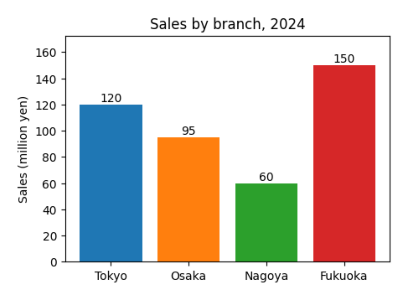

In [34]:
# 評価用の棒グラフを描いて、画像にする
BRANCHES = ["Tokyo", "Osaka", "Nagoya", "Fukuoka"]

def make_chart(values, title):
    fig, ax = plt.subplots(figsize=(5, 3.5))
    bars = ax.bar(BRANCHES, values, color=["tab:blue", "tab:orange", "tab:green", "tab:red"])
    ax.bar_label(bars)
    ax.set_ylim(0, max(values) * 1.15)   # 最も高い棒の数値ラベルが枠に重ならないよう、上に余白を取る
    ax.set_ylabel("Sales (million yen)")
    ax.set_title(title)
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf).convert("RGB")

sales_2024 = [120, 95, 60, 150]
sales_2025 = [130, 70, 90, 110]
chart_2024 = make_chart(sales_2024, "Sales by branch, 2024")
chart_2025 = make_chart(sales_2025, "Sales by branch, 2025")
show_images([chart_2024], size=5)

In [35]:
# グラフについて質問する（正解: 最大は Fukuoka の150、Tokyo と Osaka の合計は215、最大と最小の差は90）
for q in ["Which branch has the highest sales, and what is its value?",
          "What is the total sales of Tokyo and Osaka?",
          "What is the difference between the highest and the lowest bar?"]:
    a, n = ask([chart_2024], q)
    print(f"Q: {q}\nA: {a}   [入力 {n} トークン]\n")

Q: Which branch has the highest sales, and what is its value?
A: Fukuoka   [入力 238 トークン]

Q: What is the total sales of Tokyo and Osaka?
A: 215   [入力 235 トークン]

Q: What is the difference between the highest and the lowest bar?
A: 80   [入力 237 トークン]



## 結果の読み方

検証時の実行では、次のような回答になった

| 質問 | 回答 | 正解 | 判定 |
| --- | --- | --- | --- |
| 最大の支店とその値 | Fukuoka | Fukuoka、150 | 支店は正しいが、値を答えていない |
| TokyoとOsakaの合計 | 215 | 215 | 正しい |
| 最大と最小の差 | 80 | 90 | 誤り |

- 棒の上の数値と軸のラベルを読み取り、2つの値を足すことはできている
- 一方で、質問の後半（値）に答えなかったり、引き算の結果を誤ったりしている
  - 「どの棒が最大か、最小かを見つける」「値を読む」「引く」という複数の段階が必要な質問ほど、誤りやすい
- グラフの読み取りは、VLMが実用で最もよく使われる用途の1つであるが、数値をそのまま信用するのは危険である
  - 値を1つずつ読み取らせ、計算はプログラムで行う、という分担が安全である

## 文書画像の読み取り

文書の画像（請求書を模したもの）を作り、内容を質問する

- 従来は、OCR（文字認識）で文字列を取り出してから、別のプログラムで項目を探していた
- VLMは、文字の読み取りと「どれが合計金額か」の理解を同時に行う
- 文書の最下行に、小さな文字で照会番号を入れてある
  - 後で解像度の影響を調べるためである

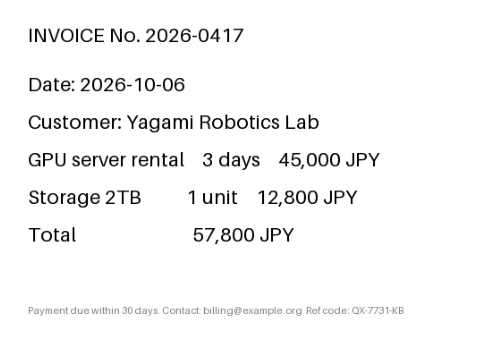

Q: What is the total amount of this invoice, and who is the customer?
A: The total amount of the invoice is 57,800 JPY. The customer is Yagami Robotics Lab.   [入力 283 トークン]

Q: How many days was the GPU server rented, and how much did it cost?
A: The GPU server was rented for 3 days, and it cost 45,000 JPY.   [入力 284 トークン]



In [36]:
# 請求書を模した文書画像を作る
def make_document():
    im = Image.new("RGB", (520, 360), "white")
    d = ImageDraw.Draw(im)
    big = ImageFont.load_default(size=22)
    small = ImageFont.load_default(size=11)
    d.text((20, 15), "INVOICE No. 2026-0417", font=big, fill="black")
    lines = ["Date: 2026-10-06", "Customer: Yagami Robotics Lab", "GPU server rental    3 days    45,000 JPY",
             "Storage 2TB          1 unit    12,800 JPY", "Total                          57,800 JPY"]
    for k, line in enumerate(lines):
        d.text((20, 70 + k * 42), line, font=big, fill="black")
    d.text((20, 330), "Payment due within 30 days. Contact: billing@example.org  Ref code: QX-7731-KB",
           font=small, fill="gray")
    return im

doc_img = make_document()
show_images([doc_img], size=6)
for q in ["What is the total amount of this invoice, and who is the customer?",
          "How many days was the GPU server rented, and how much did it cost?"]:
    a, n = ask([doc_img], q)
    print(f"Q: {q}\nA: {a}   [入力 {n} トークン]\n")

## 結果の読み方

検証時の実行では、2つの質問とも正しく答えた

- 合計金額（57,800 JPY）と顧客名（Yagami Robotics Lab）を、文書の中から選んで答えている
- 「GPUサーバのレンタルは何日で、いくらか」という質問には、該当する行から「3 days」と「45,000 JPY」を取り出している
  - 文字を読むだけでなく、行の中のどの数値が何を表すかを理解している
- 入力は約280トークンである
  - 同じ内容をテキストで渡せば数十トークンで済むので、画像として渡すのは割高である
  - それでも、表、レイアウト、手書き、印影のように、テキストに直しにくい情報をそのまま渡せる利点がある

## 複数画像の比較

VLMには複数の画像を同時に渡すことができる

- それぞれの画像が画像トークンの列になり、順に並べて入力される
- LLMのアテンションは、両方の画像のトークンを参照できる

まず、写真2枚の共通点と違いを聞く

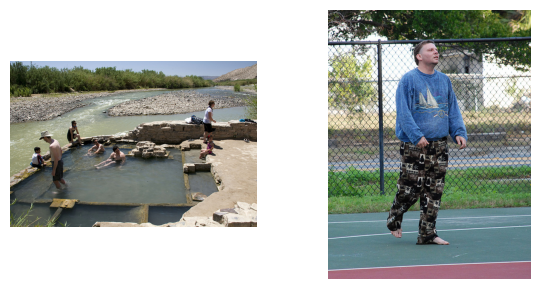

A: The two images share a common theme of people enjoying outdoor activities in natural settings. The first image shows a group of people sitting in a river, while the second image features a man standing on a tennis court. The main difference is that the first image depicts a group of people in a natural setting, while the second image shows a man in an urban environment.   [入力 488 トークン]


In [37]:
# 写真2枚を同時に渡して比べさせる
pair = [ds[val_ids[2]]["image"], ds[val_ids[7]]["image"]]
show_images(pair)
a, n = ask(pair, "What do these two images have in common, and how do they differ?", max_new_tokens=120)
print(f"A: {a}   [入力 {n} トークン]")

次に、2024年と2025年の2枚のグラフを渡して、年をまたいだ比較をさせる

- 正解は「Nagoyaが60から90へ30増えた」である
  - Tokyoは10増、Osakaは25減、Fukuokaは40減である
- 答えるには、2枚の画像から同じ支店の値を読み取り、引き算をして、比べる必要がある

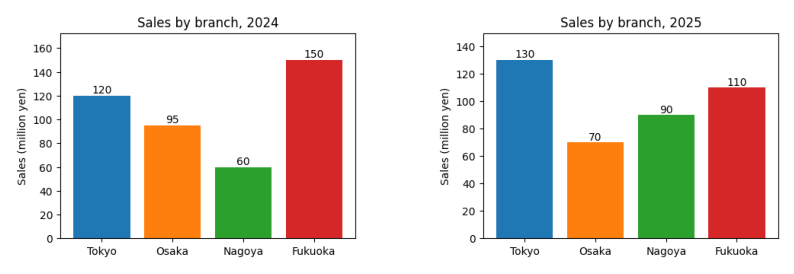

Q: The first image shows sales in 2024 and the second image shows sales in 2025. Which branch increased its sales the most from 2024 to 2025? Answer with the branch name and the amount.
A: Fukuoka   [入力 484 トークン]

Q: Compare the two charts. For each branch, write the 2024 value and the 2025 value.
A: To compare the 2024 and 2025 values for each branch, we can look at the "Sales" column for each row in the two charts.

For the Tokyo branch:
- 2024: 120 million yen
- 2025: 130 million yen

For the Osaka branch:
- 2024: 95 million yen
- 2025: 100 million yen

For the Nagoya branch:
- 2024: 60 million yen
- 2025: 65 million yen

For the Fukuoka branch:
- 2024: 15   [入力 457 トークン]

正解: {'Tokyo': (120, 130, 10), 'Osaka': (95, 70, -25), 'Nagoya': (60, 90, 30), 'Fukuoka': (150, 110, -40)}


In [38]:
# 2枚のグラフを比べさせる（正解: Nagoya が +30 で最大）
show_images([chart_2024, chart_2025], size=5)
for q in ["The first image shows sales in 2024 and the second image shows sales in 2025. "
          "Which branch increased its sales the most from 2024 to 2025? Answer with the branch name and the amount.",
          "Compare the two charts. For each branch, write the 2024 value and the 2025 value."]:
    a, n = ask([chart_2024, chart_2025], q, max_new_tokens=150)
    print(f"Q: {q}\nA: {a}   [入力 {n} トークン]\n")
print("正解:", {b: (x, y, y - x) for b, x, y in zip(BRANCHES, sales_2024, sales_2025)})

## 結果の読み方

検証時の実行では、次のような結果になった

- 写真2枚の比較では、「どちらも屋外で人が活動している」という共通点と、「川辺の人々」と「テニスコートの男性」という違いを挙げた
  - 大まかな内容の比較はできている
- グラフ2枚の比較では、**誤った**
  - 「Fukuokaが40増えた」と答えたが、実際にはFukuokaは40**減って**いる（正解はNagoyaの30増）
  - 各支店の値を書き出させると、2024年のTokyoを130、2025年を150とするなど、2枚の値が混ざったり、存在しない値が現れたりした
- グラフ1枚については値を読めていたので、文字が読めないわけではない
  - 2枚の画像の間で「同じ支店の棒」を対応づけ、どちらの値がどちらの年のものかを保ったまま比べる、という処理で誤っている

複数画像の入力は便利であるが、画像をまたいだ正確な照合は、この規模のモデルには難しい

- 確実に比べたい場合は、1枚ずつ値を読み取らせて表にし、比較はプログラムで行うとよい

---

# VLMの苦手な例

VLMは流暢に答えるので、何でも見えているように感じる
しかし、苦手な課題がはっきりある
ここでは、正解を自分で決められる図形の画像を使って、3種類の失敗を観察する

## 数を数える

白い背景に赤い円を $n$ 個描き、数を答えさせる

- 円は重ならないように配置する
- 人間なら、時間をかければ必ず正解できる課題である

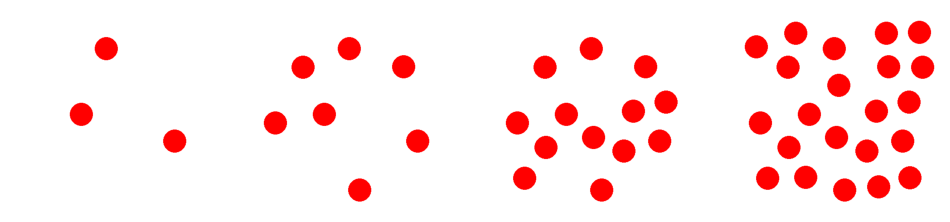

正解  3 個 -> 回答 ['3', '3', '3', '3']
正解  5 個 -> 回答 ['5', '4', '5', '5']
正解  7 個 -> 回答 ['7', '6', '6', '7']
正解 10 個 -> 回答 ['9', '8', '8', '9']
正解 13 個 -> 回答 ['11', '10', '10', '11']
正解 17 個 -> 回答 ['15', '14', '13', '13']
正解 22 個 -> 回答 ['18', '18', '18', '18']


In [39]:
# 赤い円を n 個描いた画像を作り、数を答えさせる
def make_circles(n, seed):
    r = np.random.RandomState(seed)
    im = Image.new("RGB", (448, 448), "white")
    d = ImageDraw.Draw(im)
    pts = []
    while len(pts) < n:   # 中心どうしが70画素以上離れるように置く
        x, y = r.randint(40, 408, 2)
        if all((x - a) ** 2 + (y - b) ** 2 > 70 ** 2 for a, b in pts):
            pts.append((x, y))
    for x, y in pts:
        d.ellipse([x - 25, y - 25, x + 25, y + 25], fill="red")
    return im

show_images([make_circles(n, 0) for n in [3, 7, 13, 22]], size=3)
count_result = {}
for n in [3, 5, 7, 10, 13, 17, 22]:
    answers = [ask([make_circles(n, seed)], "How many red circles are in this image? Answer with a number.")[0]
               for seed in range(4)]
    count_result[n] = answers
    print(f"正解 {n:>2} 個 -> 回答 {answers}")

## 結果の読み方

検証時の実行では、次の結果になった（各個数について、配置を変えた4枚の回答）

| 正解 | 回答 |
| --- | --- |
| 3 | 3、3、3、3 |
| 5 | 5、4、5、5 |
| 7 | 7、6、6、7 |
| 10 | 9、8、8、9 |
| 13 | 11、10、10、11 |
| 17 | 15、14、13、13 |
| 22 | 18、18、18、18 |

- 3個までは全問正解で、5〜7個では1個少なく答えることがある
- 10個以上では、すべて**少なく**答えた
  - 個数が増えるほど、ずれも大きくなる
  - 22個では、配置によらず18と答えている
- 円は重なっておらず、色も大きさも同じで、背景は白である
  - 人間にとってはこれ以上ないほど易しい条件で、この結果である
- 回答は常に数字1つで、自信がなさそうな様子は出力からは読み取れない

VLMは1個ずつ指さして数えているわけではない
画像トークン全体から「だいたいこのくらい」という数を答えていると考えると、多いほど誤差が大きくなることを説明できる

## 空間関係

3つの図形を置いた画像について、位置関係を質問する

- 左右のような単純な関係と、距離の比較のような少し込み入った関係の両方を聞く
- 図形の中心は、青い正方形が(120, 310)、緑の円が(340, 120)、橙の三角形が(350, 330)付近である
  - 青い正方形から遠いのは緑の円である

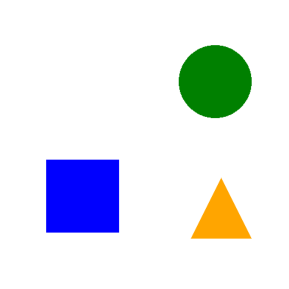

Q: Is the blue square to the left or right of the green circle?
A: The blue square is to the left of the green circle.

Q: Which shape is directly below the green circle?
A: The shape directly below the green circle is a triangle.

Q: Which is farther from the blue square: the green circle or the orange triangle?
A: The orange triangle is farther from the blue square. The green circle is located above and to the right of the blue square, while the orange triangle is located below and to the right of the blue square.

Q: If the image is flipped horizontally, which shape will be on the left side?
A: If the image is flipped horizontally, the shape that will be on the left side will be the blue square.



In [40]:
# 3つの図形の位置関係を質問する
def make_shapes():
    im = Image.new("RGB", (448, 448), "white")
    d = ImageDraw.Draw(im)
    d.rectangle([60, 250, 180, 370], fill="blue")
    d.ellipse([280, 60, 400, 180], fill="green")
    d.polygon([(300, 380), (400, 380), (350, 280)], fill="orange")
    return im

shape_img = make_shapes()
show_images([shape_img], size=3.5)
for q in ["Is the blue square to the left or right of the green circle?",
          "Which shape is directly below the green circle?",
          "Which is farther from the blue square: the green circle or the orange triangle?",
          "If the image is flipped horizontally, which shape will be on the left side?"]:
    print(f"Q: {q}\nA: {ask([shape_img], q)[0]}\n")

## 結果の読み方

検証時の実行では、次の結果になった

| 質問 | 回答 | 判定 |
| --- | --- | --- |
| 青い正方形は緑の円の左か右か | 左 | 正しい |
| 緑の円の真下にある図形 | 三角形 | 正しい |
| 青い正方形から遠いのは、緑の円か橙の三角形か | 橙の三角形 | 誤り（遠いのは緑の円） |
| 画像を左右反転すると、左側に来る図形 | 青い正方形 | 誤り（青い正方形は右側に移る） |

- 2つの図形の左右、上下のような直接の関係は答えられた
- 距離の比較では誤った
  - しかも「緑の円は右上に、橙の三角形は右下にある」という、もっともらしい理由を付けている
  - 位置の記述は正しいが、そこから距離を比べることができていない
- 左右反転の質問では、現在左にある図形をそのまま答えた
  - 画像を頭の中で操作する、という処理はできていない

「見たままを答える」質問には強いが、「見たものを使って考える」質問には弱い、という傾向がある

## 細かい文字と解像度

請求書の画像を縮小しながら、同じ質問をする

- Qwen2-VLは画像の大きさに応じてトークン数が変わるので、縮小すると画像トークンが減る
- 大きな文字で書かれた合計金額（57,800 JPY）と、小さな文字で書かれた照会番号（QX-7731-KB）の両方を聞く

In [41]:
# 文書画像の大きさを変えて、読み取りの正確さと入力トークン数を調べる
for scale in [2.0, 1.0, 0.75, 0.5, 0.35, 0.25]:
    im = doc_img.resize((int(doc_img.width * scale), int(doc_img.height * scale)))
    total, n = ask([im], "What is the total amount of this invoice? Answer with the amount only.", max_new_tokens=20)
    ref, _ = ask([im], "What is the ref code written in small letters at the bottom? Answer with the code only.",
                 max_new_tokens=20)
    print(f"scale {scale:<4} size {im.width:>4}x{im.height:<4} 入力 {n:>4} トークン | total: {total:<14} | ref code: {ref}")
print("正解: total = 57,800 JPY / ref code = QX-7731-KB")

scale 2.0  size 1040x720  入力  998 トークン | total: 57,800 JPY     | ref code: QX-7731-KB
scale 1.0  size  520x360  入力  283 トークン | total: 57,800         | ref code: OX-7731-KB
scale 0.75 size  390x270  入力  176 トークン | total: 57,800 JPY     | ref code: QX-7731-KB
scale 0.5  size  260x180  入力   90 トークン | total: 57,800         | ref code: GX-77314B
scale 0.35 size  182x125  入力   60 トークン | total: 57,800         | ref code: GH-77741
scale 0.25 size  130x90   入力   51 トークン | total: 7,670,000      | ref code: Y0000000000000000000
正解: total = 57,800 JPY / ref code = QX-7731-KB


## 結果の読み方

検証時の実行では、次の結果になった

| 縮小率 | 画像の大きさ | 入力トークン数 | 合計金額（大きな文字） | 照会番号（小さな文字） |
| --- | --- | --- | --- | --- |
| 2.0 | 1040×720 | 998 | 正しい | 正しい |
| 1.0 | 520×360 | 283 | 正しい | OX-7731-KB（QをOと誤読） |
| 0.75 | 390×270 | 176 | 正しい | 正しい |
| 0.5 | 260×180 | 90 | 正しい | GX-77314B（誤り） |
| 0.35 | 182×125 | 60 | 正しい | GH-77741（誤り） |
| 0.25 | 130×90 | 51 | 7,670,000（誤り） | Y0000...（誤り） |

- 画像を小さくすると、入力トークン数が減る
  - 面積にほぼ比例しており、「28×28画素あたり1トークン」という構造がそのまま現れている
- **小さな文字から先に読めなくなる**
  - 大きな文字の合計金額は、縮小率0.35（60トークン）まで正しく読めた
  - 小さな文字の照会番号は、縮小率0.5で誤り始めた
- 読めないときに「読めない」とは答えない
  - 形式だけは照会番号らしい文字列（GX-77314B）を作っている
  - 縮小率0.25では、合計金額として実在しない数値を答えた
- 縮小率1.0でQをOと誤読し、0.75では正しく読めている
  - 解像度と正確さの関係は、単調とは限らない
  - パッチの境界が文字のどこに来るかで、読みやすさが変わるためと考えられる
- 2倍に拡大すると正しく読めたが、トークン数は約3.5倍になった

「解像度・画像トークン数・計算量」の章で見た関係が、実際のモデルの振る舞いとして確認できた

- 読み取りの正確さが必要なら、トークン数（計算量、料金）を払って解像度を上げる
- 必要な部分だけを切り出して拡大すれば、少ないトークンで同じ効果が得られる

## なぜ苦手なのか

3つの失敗には、構造に由来する共通の理由がある

<img src="https://class.west.sd.keio.ac.jp/dataai/text/vlm-why-weak.png" width=750>

上の図は、処理の各段階で起きることを赤色で示している
下の3項目が、図の3つの箱に対応する

- **画像はパッチに切られ、パッチごとに1本のベクトルに要約される**
  - パッチより細かい情報（小さな文字の1画）は、要約の段階で失われる
  - 失われた情報は、後段のLLMがどれほど賢くても復元できない
- **画像エンコーダの多くは、画像全体と文の対応で学習されている**（CLIPの対照学習）
  - 「何が写っているか」は強く学習されるが、「いくつあるか」「どちらが左か」は、学習時の説明文にほとんど書かれていない
  - CLIPが数を数えるのを苦手とすること（`mlsys-text-J-NLP-7-CLIP-GD.ipynb` の「CLIPの問題点」を参照）が、VLMにも引き継がれている
- **LLMは、見えなかった部分をもっともらしく補ってしまう**
  - 読めない文字に対して「読めない」と答えず、ありそうな文字列を作る
  - テキストのLLMのハルシネーションと同じ現象が、画像について起きている

実用上の注意は次のとおりである

- 数値や文字列を正確に取り出す用途では、VLMの出力をそのまま信用しない
  - 解像度を上げる、領域を切り出して拡大する、OCRや物体検出と併用する、複数回聞いて一致を見る、といった対策を組み合わせる
- 数える課題は、物体検出モデル（Grounding DINOなど）に検出させてから個数を数えるほうが確実である
- 自分の用途に近い画像で、正解のわかっている小さな評価セットを作って確かめる
  - 本章で図形や文書を自作したのは、そのためである
  - 評価セットの作り方と、少数の問題で測った正解率の誤差の扱いは `mlsys-text-M-LLM-4-評価.ipynb` を参照

---

# マルチモーダルRAG

## 画像を検索してから答える

RAG（Retrieval-Augmented Generation、検索拡張生成）は、質問に関係する文書を検索し、それをLLMに渡して答えさせる手法である（`mlsys-text-M-LLM-2-Application.ipynb` を参照）

同じことを画像で行うのが**マルチモーダルRAG**である

- 何千枚、何万枚の画像をすべてVLMに入力することはできない
  - 画像1枚が数百トークンになるので、コンテキスト長も計算時間も足りない
- そこで、まず関係のありそうな画像を数枚に絞り、その数枚だけをVLMに渡す

絞り込みには、冒頭で学んだCLIPを使う

| 段階 | 使うモデル | 処理 |
| --- | --- | --- |
| 索引の作成（事前に1回） | CLIPの画像エンコーダ | 全画像を512次元のベクトルにして保存する |
| 検索 | CLIPのテキストエンコーダ | 検索文をベクトルにし、コサイン類似度の高い画像を上位 $k$ 枚取り出す |
| 生成 | VLM | 取り出した画像と質問を渡して答えさせる |

<img src="https://class.west.sd.keio.ac.jp/dataai/text/vlm-multimodal-rag.png" width=750>

上の図の上段は事前に1回だけ行う索引の作成、下段は質問のたびに行う検索と生成である

- CLIPは「選べるが書けない」、VLMは「書けるが大量には読めない」
- 2つを組み合わせると、互いの弱点を補える
- 索引は、最初に全画像を画像エンコーダに通したときに `img_emb` としてすでに作ってある

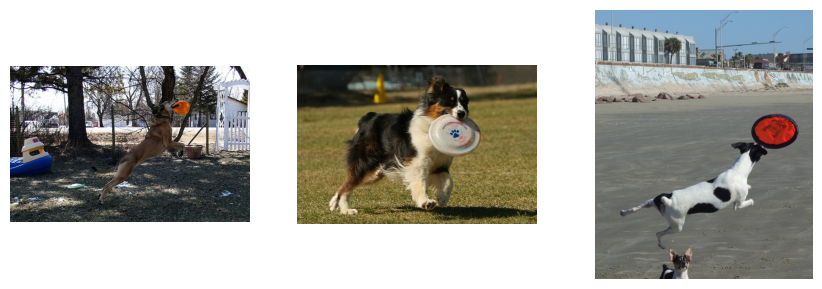

id=5305  sim=0.348  A brown dog leaps up to catch an orange toy .
id=3669  sim=0.347  A black and white dog carries a white Frisbee over the grass .
id=4991  sim=0.340  A black and white dog is jumping up to catch a toy as another dog watches .


In [42]:
# テキストで画像を検索する関数（CLIP埋め込みのコサイン類似度）
def search_images(query, k=3):
    q = encode_texts([query])                    # (1, 512)
    sims = (img_emb @ q.T).squeeze(1)            # 全画像との類似度
    top = sims.topk(k)
    return top.indices.tolist(), top.values.tolist()

query = "a dog catching a frisbee"
hit_ids, hit_sims = search_images(query)
show_images([ds[i]["image"] for i in hit_ids])
for i, s in zip(hit_ids, hit_sims):
    print(f"id={i:>4}  sim={s:.3f}  {caps[i][0]}")

検索には説明文を一切使っていない
画像の埋め込みと検索文の埋め込みを比べているだけである

- 上に表示した説明文は、検索結果が妥当かを人間が確認するためのものである

次に、検索と生成をつなぐ

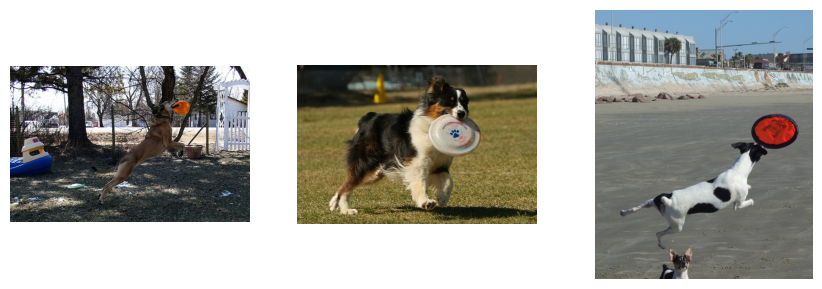

検索文: a dog catching a frisbee  ->  id=[5305, 3669, 4991]  sim=[0.348, 0.347, 0.34]
Q: What color is the dog, and what is it doing?
A（上位1枚）: The dog is brown and it is jumping in the air to catch a frisbee.   [入力 249 トークン]
A（上位3枚）: The dog is brown and white. It is jumping to catch a frisbee.   [入力 747 トークン]



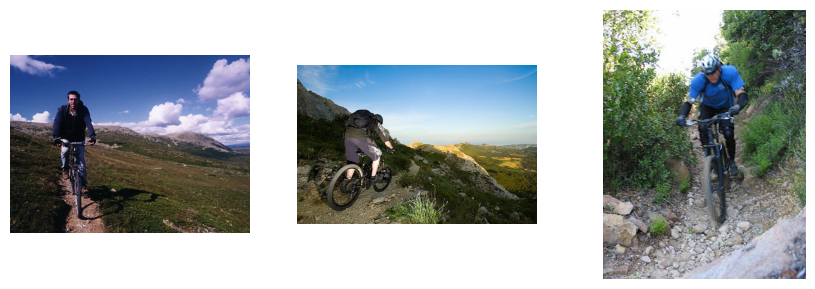

検索文: a person riding a bicycle on a mountain trail  ->  id=[4105, 3065, 973]  sim=[0.337, 0.337, 0.321]
Q: What is the person wearing?
A（上位1枚）: The person in the picture is wearing a dark-colored jacket and jeans.   [入力 261 トークン]
A（上位3枚）: The person is wearing a blue shirt, a black jacket, and a backpack.   [入力 701 トークン]



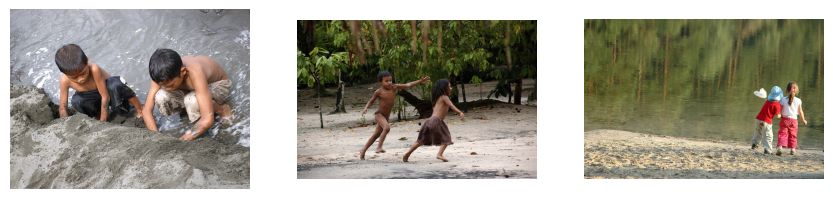

検索文: children playing on the beach  ->  id=[5091, 1805, 4919]  sim=[0.326, 0.319, 0.316]
Q: How many children are there, and what are they doing?
A（上位1枚）: There are two children in the picture. They are both kneeling in the water, digging in the sand.   [入力 267 トークン]
A（上位3枚）: There are two children in the image. They are playing in the sand and water.   [入力 727 トークン]



In [43]:
# マルチモーダルRAG: 検索した画像をVLMに渡して答えさせる
def multimodal_rag(query, question, k=3):
    ids, sims = search_images(query, k)
    images = [ds[i]["image"] for i in ids]
    show_images(images)
    print(f"検索文: {query}  ->  id={ids}  sim={[round(s, 3) for s in sims]}")
    # 上位1枚だけを渡す場合
    a1, n1 = ask(images[:1], question)
    print(f"Q: {question}\nA（上位1枚）: {a1}   [入力 {n1} トークン]")
    # 上位k枚をまとめて渡す場合
    prompt = (f"These are {k} images retrieved for the query '{query}'. "
              f"For each image, answer the question: {question}")
    ak, nk = ask(images, prompt, max_new_tokens=200)
    print(f"A（上位{k}枚）: {ak}   [入力 {nk} トークン]\n")

multimodal_rag("a dog catching a frisbee", "What color is the dog, and what is it doing?")
multimodal_rag("a person riding a bicycle on a mountain trail", "What is the person wearing?")
multimodal_rag("children playing on the beach", "How many children are there, and what are they doing?")

## 結果の読み方

検証時の実行では、3つの検索文のいずれについても、内容に合った画像が上位に並んだ

- 「a dog catching a frisbee」では、犬がフリスビーやおもちゃを取ろうとしている、またはくわえている画像が3枚取り出された
- 上位1枚を渡した場合、VLMは「犬は茶色で、跳び上がって橙色のフリスビーを取ろうとしている」と答えた
  - 6000枚の中から1枚を選び、その画像について文章で答える、という流れが成り立っている

上位3枚をまとめて渡した場合には、注意すべき点がある

- 「画像ごとに答えよ」と指示したが、回答は1つにまとめられた
  - 「茶色と白の犬」のように、複数の画像の内容が混ざった答えになっている
  - 「複数画像の比較」で見た、画像をまたいだ処理の弱さがここにも現れている
- 入力トークン数は約3倍（約250 → 約750）になる
- 渡す画像を増やせば正解の画像が含まれる可能性は上がるが、VLMが混同する危険も上がる
  - 小型のVLMでは、1枚ずつ渡して答えさせ、結果をまとめるほうが安全である

- 3番目の例では、検索文は「浜辺で遊ぶ子どもたち」であるが、類似度は0.32前後で、上位の画像どうしの差も小さい
  - CLIPの類似度は絶対値が小さく、「合っている」と「まあまあ合っている」の差がわずかである
  - 類似度の値だけで、検索結果が信頼できるかを判断するのは難しい

## 実用に向けた論点

小さなパイプラインではあるが、実用のマルチモーダルRAGと骨格は同じである
規模を大きくするときの論点を挙げる

- **検索文の作り方**
  - 利用者の質問文をそのまま検索に使うと、うまく検索できないことが多い
  - CLIPは「写真の説明文」のような文で学習されており、疑問文には慣れていない
  - LLMに質問を検索向きの語句へ書き換えさせる方法がよく使われる
- **索引の規模**
  - 数千枚なら全画像との内積で足りるが、数百万枚になると近似最近傍探索（ANN）の索引が必要になる
- **文書画像の検索**
  - スライドやPDFのページのように文字が主体の画像は、CLIPの埋め込み1本では区別しにくい
  - ページの画像をVLMで埋め込み、パッチ単位のベクトルで照合する方法（ColPaliなど）が提案されている
- **検索の誤りは生成で取り返せない**
  - 関係のない画像が渡されると、VLMはその画像についてもっともらしく答えてしまう
  - 検索結果の類似度にしきい値を設ける、VLMに「質問に関係する画像か」を先に判定させる、などの対策がある
- **評価**
  - 検索段（正しい画像が上位に入るか）と生成段（取り出した画像にもとづいて正しく答えたか）を分けて測る
  - RAGの評価の考え方は `mlsys-text-M-LLM-4-評価.ipynb` を参照
- **出典の提示**
  - 回答とともに、根拠にした画像を利用者に見せる（上のセルで画像を表示しているのはそのためである）

---

# その先へ

VLMの「何でもトークンの列にしてLLMに読ませる」という考え方は、画像以外にも広がっている
ここからは概念を中心に述べる

## 動画: フレームのサンプリングと時間情報

動画は画像（フレーム）の列である
最も単純な扱い方は、**フレームを何枚か抜き出し、複数画像として入力する**ことである（`mlsys-text-N-アプリ-transformer.ipynb` のGITによるビデオキャプションでも、フレームのサンプリングを行っている）

<img src="https://class.west.sd.keio.ac.jp/dataai/text/vlm-video-sampling.png" width=750>

上の図の橙色が抜き出したフレームである
赤色の区間のように、抜き出したフレームの間で起きた短い出来事は入力に含まれない

問題はトークン数である

In [44]:
# 動画を入力したときの画像トークン数を見積もる
def video_tokens(seconds, fps_sampled, tokens_per_frame):
    return int(seconds * fps_sampled * tokens_per_frame)

print(f"{'video length':>14}{'sampled fps':>13}{'tokens/frame':>14}{'total tokens':>14}")
for seconds, fps, tpf in [(10, 30, 576), (10, 1, 576), (60, 1, 576), (600, 1, 576), (600, 1, 64), (3600, 0.2, 64)]:
    print(f"{seconds:>12} s{fps:>13}{tpf:>14}{video_tokens(seconds, fps, tpf):>14,}")

  video length  sampled fps  tokens/frame  total tokens
          10 s           30           576       172,800
          10 s            1           576         5,760
          60 s            1           576        34,560
         600 s            1           576       345,600
         600 s            1            64        38,400
        3600 s          0.2            64        46,080


- 10秒の動画を毎秒30フレームのまま入力すると、1フレーム576トークンとして約17万トークンになる
- 毎秒1フレームに間引いても、10分の動画で約35万トークンである
- そのため、動画を扱うVLMは次の工夫を組み合わせる
  - フレームを間引く（一定間隔、または場面の変わり目だけ）
  - 1フレームあたりのトークン数を減らす（プーリング、問い合わせトークン）
  - 連続するフレームをまとめて1つのトークン列にする（隣のフレームとの差は小さいため）

もう1つの問題は**時間情報**である

- フレームを並べただけでは、LLMは「何番目に入力されたか」しかわからない
- 「何秒の時点か」を知らせるため、各フレームの前に時刻を表すテキストを挟む、位置符号化に時刻を反映する、といった方法が使われる
- 間引いたフレームの間に起きた短い出来事は、原理的に見えない
  - サンプリングの間隔は「何を見落としてよいか」の設計である

次のセルで、フレームの順序が答えに反映されるかを、小さな合成動画で確かめる

- 赤い球が左から右へ動く4フレームを作り、動く向きを質問する
- 同じフレームを逆順に渡した場合も試す

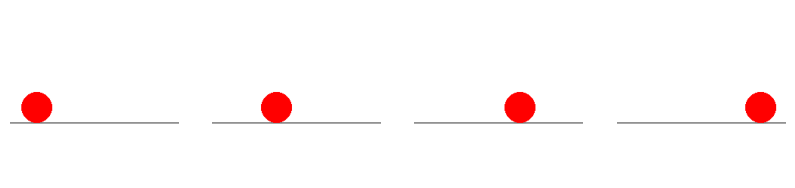

正順（左から右）: The red ball in the video moves from left to right.   [入力 312 トークン]
逆順（右から左）: The red ball in the video moves from left to right.
最初のフレーム: The red ball is on the left side of the image.
最後のフレーム: The red ball is on the right side of the image.


In [45]:
# 合成した4フレームの「動画」を複数画像として渡し、動きの向きを答えさせる
def make_frame(x):
    im = Image.new("RGB", (224, 224), "white")
    d = ImageDraw.Draw(im)
    d.line([(0, 150), (224, 150)], fill="gray", width=2)
    d.ellipse([x - 20, 110, x + 20, 150], fill="red")
    return im

frames = [make_frame(x) for x in [35, 85, 140, 190]]
show_images(frames, size=2.5)
q = ("These images are consecutive frames of a video, in time order. "
     "Does the red ball move from left to right, or from right to left?")
a_fwd, n = ask(frames, q)
a_rev, _ = ask(frames[::-1], q)
print(f"正順（左から右）: {a_fwd}   [入力 {n} トークン]")
print(f"逆順（右から左）: {a_rev}")
# 1フレームずつ見せた場合に、球の位置が読めているかを確認する
for name, f in [("最初のフレーム", frames[0]), ("最後のフレーム", frames[-1])]:
    print(f"{name}: {ask([f], 'Is the red ball on the left side or the right side of the image?')[0]}")

## 結果の読み方

検証時の実行では、次の結果になった

- 正順（球が左から右へ動く）では「left to right」と答え、正しい
- **逆順（球が右から左へ動く）でも「left to right」と答えた**
- 1フレームずつ見せると、最初のフレームでは「左」、最後のフレームでは「右」と、球の位置は正しく読めている

つまり、各フレームの中身は読めているが、**フレームの順序を答えに反映できていない**

- 4枚の画像のトークンは、入力列の中で順に並んでいる
  - しかし、モデルが「どの画像トークンが何枚目のものか」を追って動きを組み立てるとは限らない
- 質問文の選択肢の並び順や、「物は左から右へ動く」という先入観に引きずられた可能性がある
- 動画を理解するには、フレームを並べて入力できるだけでは足りず、時間の順序を扱う学習が必要であることがわかる
  - Qwen2-VLは動画入力にも対応しているが、ここでは画像4枚として渡しており、動画としての扱いは試していない

この結果は、小型のモデルと単純な合成画像での1例である
動画への対応は、モデルと入力方法によって大きく異なる

## 音声入力

音声も、同じ考え方でLLMに入力できる

- 音声の波形をメルスペクトログラムに変換し、音声エンコーダ（Whisperのエンコーダなど）で特徴の列にする（音声の特徴量は `mlsys-text-G-音声処理-1-音声識別.ipynb` を参照）
- 特徴の列をプロジェクタでLLMの埋め込み空間に写し、**音声トークン**として入力する
- 構造は、画像エンコーダを音声エンコーダに取り替えただけである

<img src="https://class.west.sd.keio.ac.jp/dataai/text/vlm-audio-input.png" width=750>

上の図を「VLMの基本構造」の図と見比べると、入力側の部品が替わっただけであることがわかる

音声を一度文字に起こしてからLLMに渡す方法（音声認識 → LLM）との違いは次のとおりである

| | 文字起こしを経由 | 音声トークンを直接入力 |
| --- | --- | --- |
| 構成 | 音声認識モデル ＋ テキストのLLM | 音声エンコーダ ＋ プロジェクタ ＋ LLM |
| 伝わる情報 | 言葉の内容だけ | 声の調子、話者、環境音なども伝わりうる |
| 実装 | 既存の部品をつなぐだけ | 位置合わせの学習が必要 |
| 誤りの伝わり方 | 認識誤りがそのままLLMに渡る | LLMが文脈から補える余地がある |

- 音声は時間方向に長いので、トークン数の問題は画像と同様に起きる
  - 音声エンコーダの出力を間引いたりまとめたりしてから入力する

## 入力から出力へ: 統合モデル

ここまでのVLMは、画像を**入力**として読むだけで、出力はテキストである
画像の**生成**まで1つのモデルで行う統合モデルも研究されている

主な考え方は2つある

<img src="https://class.west.sd.keio.ac.jp/dataai/text/vlm-unified-model.png" width=750>

上の図の (a) と (b) が、以下の2つの考え方に対応する

- **画像を離散トークンにして、語彙に加える**
  - 画像をVQ-VAEのような量子化器で離散的な符号の列に変換する（量子化の考え方は `mlsys-text-B-AutoEncoder.ipynb` を参照）
  - 符号をLLMの語彙に追加すれば、LLMはテキストと画像の符号が混ざった列を、次トークン予測で読むことも書くこともできる
  - Chameleon（2024）がこの方式の例である
  - 入力と出力が同じ表現になる一方で、量子化で細部が失われるため、読み取りの精度は連続的な特徴を使うVLMに劣りやすい
- **LLMに拡散モデルをつなぐ**
  - LLMが出力した特徴を条件として、拡散モデル（`mlsys-text-L-Diffusion-1.ipynb` を参照）に画像を生成させる
  - 理解には連続的な特徴、生成には拡散モデルと、得意な部品を使い分ける

- 2026年時点で、理解と生成のどちらも単独のモデルと同等にこなす統合の仕方は、まだ定まっていない

## ロボット制御: VLA

**VLA（Vision-Language-Action model、視覚言語行動モデル）**は、VLMの出力を「行動」にしたものである

- 入力: カメラ画像と、言葉による指示（例: 「赤いブロックを箱に入れよ」）
- 出力: ロボットの動作（手先の位置と姿勢の変化量、グリッパの開閉など）

<img src="https://class.west.sd.keio.ac.jp/dataai/text/vlm-vla.png" width=750>

上の図のように、VLAは画像と指示を受け取り、行動を表すトークンを出力する
動いた後の画像を再び入力することを繰り返す

行動をLLMに出力させる方法の1つは、**行動もトークンにする**ことである

- 連続値の動作を、各次元ごとに一定数（例: 256段階）の区間に離散化する
- 各区間を1つのトークンに割り当てる
- VLMを、画像と指示から行動トークンを出力するように追加学習する
  - RT-2（Brohan et al., 2023）やOpenVLA（Kim et al., 2024）がこの方式である

VLMを土台にする利点は、インターネット上の画像とテキストから得た知識を、ロボットの制御に持ち込めることである

- ロボットの実演データに含まれない物体や言い回しにも、ある程度対応できる
- 強化学習（`mlsys-text-D-強化学習.ipynb` を参照）のように試行錯誤で一から学習するのではなく、人が操作した実演データを模倣する形で学習することが多い

課題も多い

- 行動は高い頻度（毎秒数十回）で出す必要があるが、大きなVLMの推論は遅い
- 離散化すると、滑らかで精密な動作が難しくなる
  - 行動の出力部分だけを拡散モデルなどの連続値を出す方式にする研究が進んでいる
- 誤った行動は物理的な損害につながるので、テキストの誤りよりも安全性の要求が厳しい
  - AIシステムの安全性の評価と運用は `mlsys-text-R-安全性と公平性.ipynb` を参照
- VLAは、観測を受け取り行動を出力することを繰り返す点で、エージェントの一種である（LLMエージェントの設計は `mlsys-text-M-LLM-5-Agent設計.ipynb` を参照）

---

# まとめ

本テキストでは、VLMの内部構造を、自作と公開モデルの両面から学んだ

| 章 | 内容 | 核心 |
| --- | --- | --- |
| CLIPからVLMへ | 類似度は測れるが生成はできない | LLMに画像を読ませる必要がある |
| 基本構造 | 画像エンコーダ ＋ 接続部 ＋ LLM | 画像を、単語埋め込みと同じ空間の「画像トークン」にする |
| 接続方式 | 射影、問い合わせトークン、クロスアテンション挿入 | トークン数、細部の保持、実装の複雑さの兼ね合い |
| 最小のVLM | プロジェクタだけを学習 | 凍結した2つのモデルの間の通訳を育てれば、説明文が出る |
| 2段階の学習 | 位置合わせ → 指示チューニング | 読めるようにしてから、答え方を教える |
| 解像度と計算量 | 解像度2倍でトークン4倍 | 細かく見るほど高くつく |
| 公開VLM | 写真、図表、文書、複数画像 | 流暢だが、数、位置、細かい文字は誤る |
| マルチモーダルRAG | CLIPで検索、VLMで生成 | 選ぶモデルと書くモデルを組み合わせる |
| その先 | 動画、音声、統合モデル、VLA | 何でもトークンにしてLLMに読ませ、書かせる |

**VLMは「見えている」のではなく、「画像から作ったトークン列を読んでいる」**

- トークンに残らなかった情報は、答えに現れない
- この見方を持っていれば、VLMがどこで間違えるかを予想し、解像度、切り出し、検索、他のモデルとの併用といった対策を選ぶことができる

---

# 課題1（プロジェクタの比較実験）

自作VLMの接続部を変えて、説明文の質への影響を調べよ

1. 次の3つのプロジェクタを、同じエポック数で学習する
   - 線形層1つ（`nn.Linear(D_VIS, D_LM)`）
   - 本テキストの2層MLP
   - 問い合わせトークン方式で、問い合わせトークンの数を2、8、32に変えたもの
2. それぞれについて、評価損失、単語の一致率、入れ替え対照の一致率、1エポックの学習時間を表にまとめる
3. 評価用画像を5枚選び、各プロジェクタが生成した説明文を並べて示す
4. 画像トークンの数と説明文の質の関係について、結果にもとづいて考察する

# 課題2（VLMの弱点の調査）

公開されている小型VLMについて、本テキストで扱っていない弱点を1つ見つけ、定量的に示せ

1. 調べる能力を1つ決める（例: 時計の読み取り、図形の大小比較、色の識別、線の交差の数、回転した文字の読み取り）
2. 正解のわかっている画像を、プログラムで20枚以上生成する
3. VLMに回答させ、正解率を求める
4. 画像の解像度、または質問の言い回しを変えて、正解率がどう変わるかを調べる
5. なぜその課題が苦手なのかを、VLMの構造（パッチ分割、画像エンコーダの学習方法、LLMの補完）に結びつけて考察する

# 課題3（マルチモーダルRAGの改良）

本テキストのマルチモーダルRAGを改良し、効果を示せ

1. 質問文を5つ以上用意する（検索文は与えず、質問文だけを入力とする）
2. 質問文をそのままCLIPの検索に使った場合の検索結果を記録する
3. 次のいずれか1つ以上を実装する
   - 質問文を検索向きの語句に書き換えてから検索する（書き換えの方法は自由）
   - 検索した上位5枚をVLMに1枚ずつ見せ、質問に関係するかを判定させて絞り込む
   - 類似度にしきい値を設け、該当する画像がない場合は「見つからない」と答える
4. 改良の前後で、検索された画像と最終的な回答がどう変わったかを、例を挙げて比較する
5. 改良によって増えた計算量（VLMの呼び出し回数、入力トークン数）を示し、効果に見合うかを考察する

# 参考文献

- Radford, A. et al. (2021). "Learning Transferable Visual Models From Natural Language Supervision." ICML 2021.
- Dosovitskiy, A. et al. (2021). "An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale." ICLR 2021.
- Tsimpoukelli, M. et al. (2021). "Multimodal Few-Shot Learning with Frozen Language Models." NeurIPS 2021.
- Mokady, R., Hertz, A., and Bermano, A. H. (2021). "ClipCap: CLIP Prefix for Image Captioning." arXiv:2111.09734.
- Alayrac, J.-B. et al. (2022). "Flamingo: a Visual Language Model for Few-Shot Learning." NeurIPS 2022.
- Li, J. et al. (2023). "BLIP-2: Bootstrapping Language-Image Pre-training with Frozen Image Encoders and Large Language Models." ICML 2023.
- Liu, H. et al. (2023). "Visual Instruction Tuning." NeurIPS 2023.
- Liu, H. et al. (2024). "Improved Baselines with Visual Instruction Tuning." CVPR 2024.
- Zhai, X. et al. (2023). "Sigmoid Loss for Language Image Pre-Training." ICCV 2023.
- Wang, P. et al. (2024). "Qwen2-VL: Enhancing Vision-Language Model's Perception of the World at Any Resolution." arXiv:2409.12191.
- Marafioti, A. et al. (2025). "SmolVLM: Redefining small and efficient multimodal models." arXiv:2504.05299.
- Allal, L. B. et al. (2025). "SmolLM2: When Smol Goes Big -- Data-Centric Training of a Small Language Model." arXiv:2502.02737.
- Hodosh, M., Young, P., and Hockenmaier, J. (2013). "Framing Image Description as a Ranking Task: Data, Models and Evaluation Metrics." Journal of Artificial Intelligence Research, 47.
- Faysse, M. et al. (2025). "ColPali: Efficient Document Retrieval with Vision Language Models." ICLR 2025.
- Chameleon Team (2024). "Chameleon: Mixed-Modal Early-Fusion Foundation Models." arXiv:2405.09818.
- Brohan, A. et al. (2023). "RT-2: Vision-Language-Action Models Transfer Web Knowledge to Robotic Control." CoRL 2023.
- Kim, M. J. et al. (2024). "OpenVLA: An Open-Source Vision-Language-Action Model." CoRL 2024.
- Radford, A. et al. (2023). "Robust Speech Recognition via Large-Scale Weak Supervision." ICML 2023.
- Hugging Face Transformers Documentation. https://huggingface.co/docs/transformers/